# SCENIC+ Cross-Species Summary

This notebook summarizes SCENIC+ results across species and seeds. It covers:

- Detected TFs, regulons, and regulon sizes per species and per seed
- Stability across seeds (detected in all runs, unique to single runs, total union)
- Cross-species conservation of TFs and links
  - TF-target gene
  - TF-enhancer
  - enhancer-target gene
- Enhancer mapping to `peak_id` by coordinate overlap with species peak BED files

In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
SCENICPLUS_ROOT = Path('/home/jjanssens/jjans/analysis/adult_intestine/scenicplus')
PEAKS_ROOT = Path('/home/jjanssens/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/10_final')

MIN_SEED_SUPPORT_FOR_CONSENSUS = 1  # increase to require reproducibility across seeds

RUN_DIR_RE = re.compile(r'^scplus_pipeline_(?P<species>[A-Za-z0-9]+)_seed(?P<seed>\d+)_dsMin$')
REQUIRED_EREG_COLS = ['TF', 'Gene', 'Region', 'eRegulon_name']

species_order = ['Human', 'Chimpanzee', 'Bonobo', 'Gorilla', 'Macaque', 'Marmoset']

In [3]:
def discover_runs(root: Path) -> pd.DataFrame:
    records = []
    for d in sorted(root.glob('scplus_pipeline_*_seed*_dsMin')):
        m = RUN_DIR_RE.match(d.name)
        if not m:
            continue
        ereg_path = d / 'Snakemake' / 'eRegulons_extended.tsv'
        if not ereg_path.exists():
            continue
        species = m.group('species')
        seed = int(m.group('seed'))
        records.append({
            'species': species,
            'seed': seed,
            'run_dir': d,
            'ereg_path': ereg_path,
        })
    if not records:
        raise FileNotFoundError(f'No eRegulons_extended.tsv files found in {root}')
    df = pd.DataFrame(records).sort_values(['species', 'seed']).reset_index(drop=True)
    return df


runs_df = discover_runs(SCENICPLUS_ROOT)
runs_df.head(), runs_df.groupby('species')['seed'].nunique().sort_index()

(  species  seed                                            run_dir                                          ereg_path
 0  Bonobo     1  /home/jjanssens/jjans/analysis/adult_intestine...  /home/jjanssens/jjans/analysis/adult_intestine...
 1  Bonobo     2  /home/jjanssens/jjans/analysis/adult_intestine...  /home/jjanssens/jjans/analysis/adult_intestine...
 2  Bonobo     3  /home/jjanssens/jjans/analysis/adult_intestine...  /home/jjanssens/jjans/analysis/adult_intestine...
 3  Bonobo     4  /home/jjanssens/jjans/analysis/adult_intestine...  /home/jjanssens/jjans/analysis/adult_intestine...
 4  Bonobo     5  /home/jjanssens/jjans/analysis/adult_intestine...  /home/jjanssens/jjans/analysis/adult_intestine...,
 species
 Bonobo        20
 Chimpanzee    20
 Gorilla       20
 Human         20
 Macaque       20
 Marmoset      20
 Name: seed, dtype: int64)

In [4]:
def load_eregulons(runs: pd.DataFrame) -> pd.DataFrame:
    frames = []
    for row in runs.itertuples(index=False):
        tmp = pd.read_csv(row.ereg_path, sep='\t', usecols=REQUIRED_EREG_COLS, dtype='string')
        tmp['species'] = row.species
        tmp['seed'] = row.seed
        tmp['run_id'] = f'{row.species}_seed{row.seed}'
        frames.append(tmp)
    out = pd.concat(frames, ignore_index=True)
    out = out.dropna(subset=['TF', 'Gene', 'Region', 'eRegulon_name'])
    return out


ereg = load_eregulons(runs_df)
ereg.shape, ereg[['species', 'seed']].drop_duplicates().shape

((9766123, 7), (120, 2))

## Per-run summaries

In [5]:
run_summary = (
    ereg.groupby(['species', 'seed'], as_index=False)
    .agg(
        n_rows=('TF', 'size'),
        n_tfs=('TF', 'nunique'),
        n_regulons=('eRegulon_name', 'nunique'),
        n_target_genes=('Gene', 'nunique'),
        n_regions=('Region', 'nunique'),
    )
)
run_summary = run_summary.sort_values(['species', 'seed']).reset_index(drop=True)
run_summary.head(12)

,species,seed,n_rows,n_tfs,n_regulons,n_target_genes,n_regions
0,Bonobo,1,67480,54,74,8200,32647
1,Bonobo,2,66688,58,77,8420,32883
2,Bonobo,3,64601,56,76,8205,31262
3,Bonobo,4,68796,58,79,8447,33793
4,Bonobo,5,71219,61,81,8647,34965
5,Bonobo,6,67466,56,74,8336,31939
6,Bonobo,7,83075,57,77,8751,38876
7,Bonobo,8,73255,60,82,8459,34670
8,Bonobo,9,70798,59,83,8342,33660
9,Bonobo,10,69891,60,81,8503,33398


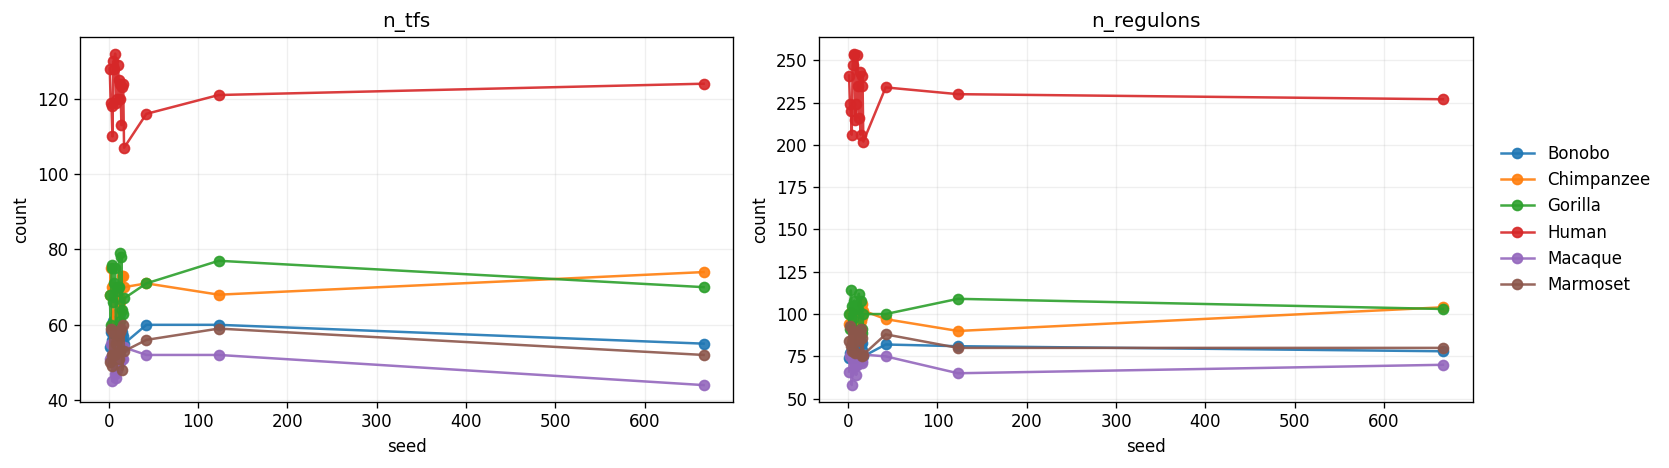

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=120)

for i, metric in enumerate(['n_tfs', 'n_regulons']):
    ax = axes[i]
    tmp = run_summary.copy()
    tmp['species_seed'] = tmp['species'] + '_s' + tmp['seed'].astype(str)
    for sp, grp in tmp.groupby('species'):
        grp = grp.sort_values('seed')
        ax.plot(grp['seed'], grp[metric], marker='o', label=sp, alpha=0.9)
    ax.set_title(metric)
    ax.set_xlabel('seed')
    ax.set_ylabel('count')
    ax.grid(alpha=0.2)

axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

## Seed stability per species

For TFs and regulons we compute, per species:

- `in_all_runs`: detected in every seed run
- `unique_to_single_run`: detected in exactly one seed run
- `total_union`: detected in at least one run
- `mean_unique_per_run`: average count of run-specific elements per seed

In [7]:
def summarize_presence(df: pd.DataFrame, value_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    species_rows = []
    per_seed_rows = []

    for species, sp_df in df.groupby('species'):
        seed_sets = {seed: set(g[value_col].dropna().unique()) for seed, g in sp_df.groupby('seed')}
        seeds = sorted(seed_sets)

        counts = Counter()
        for s in seeds:
            counts.update(seed_sets[s])

        union_set = set(counts.keys())
        in_all = {x for x, c in counts.items() if c == len(seeds)}
        unique_single = {x for x, c in counts.items() if c == 1}

        unique_counts = {}
        for s in seeds:
            others = set().union(*[seed_sets[o] for o in seeds if o != s]) if len(seeds) > 1 else set()
            unique_to_seed = seed_sets[s] - others
            unique_counts[s] = len(unique_to_seed)
            per_seed_rows.append({
                'species': species,
                'seed': s,
                'value_type': value_col,
                'detected_in_seed': len(seed_sets[s]),
                'unique_to_seed': len(unique_to_seed),
            })

        species_rows.append({
            'species': species,
            'value_type': value_col,
            'n_seeds': len(seeds),
            'in_all_runs': len(in_all),
            'unique_to_single_run': len(unique_single),
            'total_union': len(union_set),
            'mean_unique_per_run': np.mean(list(unique_counts.values())) if unique_counts else 0.0,
        })

    species_summary = pd.DataFrame(species_rows).sort_values(['value_type', 'species']).reset_index(drop=True)
    per_seed_summary = pd.DataFrame(per_seed_rows).sort_values(['value_type', 'species', 'seed']).reset_index(drop=True)
    return species_summary, per_seed_summary


tf_species_stability, tf_seed_uniques = summarize_presence(ereg, 'TF')
reg_species_stability, reg_seed_uniques = summarize_presence(ereg, 'eRegulon_name')

species_stability = pd.concat([tf_species_stability, reg_species_stability], ignore_index=True)
seed_uniques = pd.concat([tf_seed_uniques, reg_seed_uniques], ignore_index=True)

species_stability

,species,value_type,n_seeds,in_all_runs,unique_to_single_run,total_union,mean_unique_per_run
0,Bonobo,TF,20,40,21,98,1.05
1,Chimpanzee,TF,20,31,30,141,1.50
2,Gorilla,TF,20,32,26,141,1.30
3,Human,TF,20,50,31,209,1.55
4,Macaque,TF,20,30,19,95,0.95
5,Marmoset,TF,20,25,21,109,1.05
6,Bonobo,eRegulon_name,20,48,31,147,1.55
7,Chimpanzee,eRegulon_name,20,36,41,219,2.05
8,Gorilla,eRegulon_name,20,38,43,223,2.15
9,Human,eRegulon_name,20,79,80,471,4.00


In [8]:
seed_uniques.head(20)

,species,seed,value_type,detected_in_seed,unique_to_seed
0,Bonobo,1,TF,54,1
1,Bonobo,2,TF,58,2
2,Bonobo,3,TF,56,0
3,Bonobo,4,TF,58,5
4,Bonobo,5,TF,61,2
5,Bonobo,6,TF,56,1
6,Bonobo,7,TF,57,0
7,Bonobo,8,TF,60,1
8,Bonobo,9,TF,59,0
9,Bonobo,10,TF,60,1


## Regulon size summaries

In [9]:
regulon_sizes = (
    ereg.groupby(['species', 'seed', 'eRegulon_name'], as_index=False)
    .agg(
        n_links=('TF', 'size'),
        n_target_genes=('Gene', 'nunique'),
        n_regions=('Region', 'nunique'),
        tf=('TF', 'first'),
    )
)

regulon_size_species = (
    regulon_sizes.groupby('species')
    .agg(
        n_regulons=('eRegulon_name', 'nunique'),
        median_links=('n_links', 'median'),
        mean_links=('n_links', 'mean'),
        p90_links=('n_links', lambda x: np.percentile(x, 90)),
        median_targets=('n_target_genes', 'median'),
        median_regions=('n_regions', 'median'),
    )
    .reset_index()
)

regulon_size_species

,species,n_regulons,median_links,mean_links,p90_links,median_targets,median_regions
0,Bonobo,147,349.5,885.564780,2374.5,205.0,316.5
1,Chimpanzee,219,206.0,1017.131070,2867.0,123.0,182.0
2,Gorilla,223,255.0,873.245020,2400.1,146.5,241.5
3,Human,471,80.0,443.787668,1190.0,53.0,77.0
4,Macaque,158,280.5,871.798307,2218.5,175.0,264.5
5,Marmoset,191,264.0,821.298926,2005.0,145.0,251.0


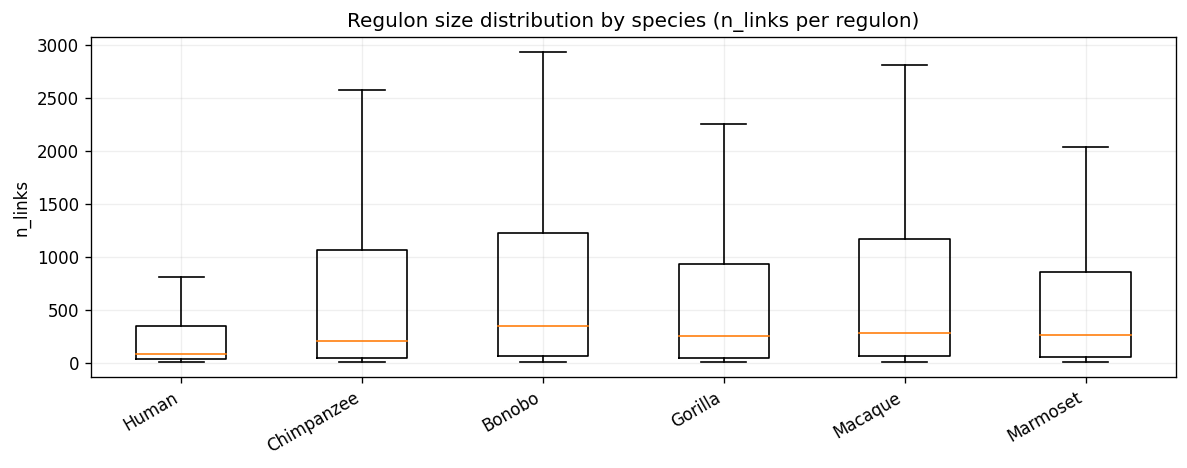

In [10]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
ordered_species = [s for s in species_order if s in regulon_sizes['species'].unique()]
data = [regulon_sizes.loc[regulon_sizes['species'] == s, 'n_links'].values for s in ordered_species]
ax.boxplot(data, labels=ordered_species, showfliers=False)
ax.set_title('Regulon size distribution by species (n_links per regulon)')
ax.set_ylabel('n_links')
ax.grid(alpha=0.2)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Map enhancer regions to peak_id by overlap

`Region` strings from SCENIC+ are parsed into genomic intervals and overlapped with species-specific peak BED files.
If multiple peaks overlap, the peak with the largest overlap is chosen.

In [11]:
def normalize_chrom(chrom):
    """Normalize chromosome name to chr-prefixed format (e.g., '1' -> 'chr1', 'chr1' -> 'chr1').
    Applied to both SCENIC+ regions and peak BED files so they use the same format.
    For species whose BED files have no chr prefix (e.g. Marmoset), both sides get prefixed."""
    if pd.isna(chrom):
        return pd.NA
    c = str(chrom).strip()
    # handle capitalisation variants
    if c.upper().startswith('CHR'):
        c = 'chr' + c[3:]
    else:
        c = 'chr' + c
    # unify mitochondrial naming
    if c in {'chrMT', 'chrMt'}:
        c = 'chrM'
    return c


def parse_region_col(region_series: pd.Series) -> pd.DataFrame:
    """Parse 'chr:start-end' or '1:start-end' region strings into chrom/start/end columns."""
    parsed = region_series.str.extract(r'^(?P<chrom>[^:]+):(?P<start>\d+)-(?P<end>\d+)$')
    parsed['chrom'] = parsed['chrom'].map(normalize_chrom)
    parsed['start'] = pd.to_numeric(parsed['start'], errors='coerce')
    parsed['end']   = pd.to_numeric(parsed['end'],   errors='coerce')
    return parsed


def load_species_peaks(species: str) -> pd.DataFrame:
    """Load peak BED file for a species, normalising chromosome names."""
    path = PEAKS_ROOT / f'all_peaks_{species}.bed'
    if not path.exists():
        raise FileNotFoundError(f'Missing peak BED for {species}: {path}')
    peaks = pd.read_csv(path, sep='\t', header=None, names=['chrom', 'start', 'end', 'peak_id'])
    peaks['chrom'] = peaks['chrom'].map(normalize_chrom)
    peaks['start'] = peaks['start'].astype(int)
    peaks['end']   = peaks['end'].astype(int)
    peaks['region_key'] = (peaks['chrom'] + ':' + peaks['start'].astype(str)
                           + '-' + peaks['end'].astype(str))
    return peaks


def build_peak_bin_index(peaks: pd.DataFrame, bin_size: int = 10_000):
    """Bin peak intervals by position for fast overlap lookup."""
    by_chrom = {}
    bins = defaultdict(lambda: defaultdict(list))
    for chrom, grp in peaks.groupby('chrom', sort=False):
        starts = grp['start'].to_numpy(dtype=np.int64)
        ends   = grp['end'].to_numpy(dtype=np.int64)
        ids    = grp['peak_id'].to_numpy(dtype=object)
        by_chrom[chrom] = {'starts': starts, 'ends': ends, 'ids': ids}
        for i, (s, e) in enumerate(zip(starts, ends)):
            for b in range(int(s) // bin_size, max(int(e) - 1, int(s)) // bin_size + 1):
                bins[chrom][b].append(i)
    return by_chrom, bins


def map_regions_to_peak_ids(regions_df: pd.DataFrame, peaks: pd.DataFrame,
                             bin_size: int = 10_000) -> pd.Series:
    """For each region in *regions_df* find the best-overlapping peak_id.

    Returns a Series the same length as *regions_df* (positional, no index alignment).
    """
    exact = peaks.set_index('region_key')['peak_id'].to_dict()
    by_chrom, peak_bin_index = build_peak_bin_index(peaks, bin_size=bin_size)

    out = []
    for row in regions_df.itertuples(index=False):
        if pd.isna(row.chrom) or pd.isna(row.start) or pd.isna(row.end):
            out.append(pd.NA)
            continue

        qstart = int(row.start)
        qend   = int(row.end)
        key    = f'{row.chrom}:{qstart}-{qend}'

        # 1. exact key hit (most common when regions ARE the peaks)
        if key in exact:
            out.append(exact[key])
            continue

        # 2. overlap search
        if row.chrom not in by_chrom:
            out.append(pd.NA)
            continue

        chrom_bins  = peak_bin_index[row.chrom]
        b0 = qstart // bin_size
        b1 = max(qend - 1, qstart) // bin_size

        candidate_idx: set = set()
        for b in range(b0, b1 + 1):
            candidate_idx.update(chrom_bins.get(b, []))

        chrom_data  = by_chrom[row.chrom]
        pk_starts   = chrom_data['starts']
        pk_ends     = chrom_data['ends']
        pk_ids      = chrom_data['ids']

        best_peak   = None
        best_overlap = -1
        for ci in candidate_idx:
            ov = min(qend, int(pk_ends[ci])) - max(qstart, int(pk_starts[ci]))
            if ov > 0 and ov > best_overlap:
                best_overlap = ov
                best_peak    = pk_ids[ci]

        out.append(best_peak if best_peak is not None else pd.NA)

    return pd.Series(out, dtype='string')  # positional — caller must NOT rely on index


# ── Drop columns added by a previous run of this cell (makes re-runs safe) ───────
_extra_cols = ['region_chrom', 'region_start', 'region_end', 'peak_id']
ereg = ereg.drop(columns=[c for c in _extra_cols if c in ereg.columns])

# ── Parse Region strings → normalised coordinates ────────────────────────────────
parsed = parse_region_col(ereg['Region'])
ereg[['region_chrom', 'region_start', 'region_end']] = parsed[['chrom', 'start', 'end']]

# ── Load & normalise peak BED files (chr-normalised) ─────────────────────────────
peak_map_dfs = {sp: load_species_peaks(sp) for sp in sorted(ereg['species'].unique())}

# ── Map unique regions per species (one lookup, then merge back) ──────────────────
# Works on the deduplicated (species, Region) table → much faster than row-by-row.
unique_regions = (
    ereg[['species', 'Region', 'region_chrom', 'region_start', 'region_end']]
    .drop_duplicates()
    .reset_index(drop=True)   # fresh 0-based index
)
unique_regions['peak_id'] = pd.Series(pd.NA, index=unique_regions.index, dtype='string')

for sp, sp_idx in unique_regions.groupby('species').groups.items():
    sub = (unique_regions.loc[sp_idx, ['region_chrom', 'region_start', 'region_end']]
           .rename(columns={'region_chrom': 'chrom', 'region_start': 'start',
                            'region_end': 'end'}))
    # *** CRITICAL: use .values so the returned Series (index 0,1,2…)
    # *** does NOT misalign with sp_idx (which is a non-zero-based slice).
    unique_regions.loc[sp_idx, 'peak_id'] = (
        map_regions_to_peak_ids(sub, peak_map_dfs[sp]).values
    )

ereg = ereg.merge(
    unique_regions[['species', 'Region', 'peak_id']],
    on=['species', 'Region'],
    how='left',
)

map_stats = (
    unique_regions.assign(mapped=unique_regions['peak_id'].notna())
    .groupby('species')['mapped']
    .agg(['sum', 'count'])
    .assign(mapping_rate=lambda x: (x['sum'] / x['count']).round(4))
    .reset_index()
)
map_stats

,species,sum,count,mapping_rate
0,Bonobo,61657,62683,0.9836
1,Chimpanzee,85172,86671,0.9827
2,Gorilla,90337,92291,0.9788
3,Human,102193,102977,0.9924
4,Macaque,61468,62886,0.9775
5,Marmoset,82523,88276,0.9348


## Build species-level consensus sets

For each species, each element is retained if detected in at least `MIN_SEED_SUPPORT_FOR_CONSENSUS` seed runs.

In [12]:
def species_consensus_sets(ereg_df: pd.DataFrame, min_seed_support: int = 1):
    specs = {}

    for sp, sp_df in ereg_df.groupby('species'):
        n_seeds = sp_df['seed'].nunique()

        tf_support = (
            sp_df[['seed', 'TF']].drop_duplicates().groupby('TF')['seed'].nunique()
        )
        tf_set = set(tf_support[tf_support >= min_seed_support].index)

        tf_gene_support = (
            sp_df[['seed', 'TF', 'Gene']].drop_duplicates().groupby(['TF', 'Gene'])['seed'].nunique()
        )
        tf_gene_set = set(tf_gene_support[tf_gene_support >= min_seed_support].index)

        tf_enhancer_support = (
            sp_df[['seed', 'TF', 'peak_id']].dropna().drop_duplicates().groupby(['TF', 'peak_id'])['seed'].nunique()
        )
        tf_enhancer_set = set(tf_enhancer_support[tf_enhancer_support >= min_seed_support].index)

        enhancer_gene_support = (
            sp_df[['seed', 'peak_id', 'Gene']].dropna().drop_duplicates().groupby(['peak_id', 'Gene'])['seed'].nunique()
        )
        enhancer_gene_set = set(enhancer_gene_support[enhancer_gene_support >= min_seed_support].index)

        specs[sp] = {
            'n_seeds': n_seeds,
            'tf': tf_set,
            'tf_gene': tf_gene_set,
            'tf_enhancer': tf_enhancer_set,
            'enhancer_gene': enhancer_gene_set,
        }

    return specs


cons_sets = species_consensus_sets(ereg, min_seed_support=MIN_SEED_SUPPORT_FOR_CONSENSUS)
sorted(cons_sets.keys())

['Bonobo', 'Chimpanzee', 'Gorilla', 'Human', 'Macaque', 'Marmoset']

## Cross-species conservation

For each feature class, report:

- Per-species totals
- Number conserved in all species
- Number present in exactly k species
- Pairwise overlap and Jaccard similarity

In [13]:
def conservation_tables(consensus_sets: dict, key: str):
    species = sorted(consensus_sets.keys(), key=lambda x: (species_order.index(x) if x in species_order else 999, x))
    sets = {sp: consensus_sets[sp][key] for sp in species}

    # Per-species total
    totals = pd.DataFrame({
        'species': species,
        'n_elements': [len(sets[s]) for s in species],
    })

    # Presence across species
    counter = Counter()
    for sp in species:
        counter.update(sets[sp])

    present_k = (
        pd.Series(Counter(counter.values()), name='n_elements')
        .rename_axis('present_in_n_species')
        .sort_index()
        .reset_index()
    )

    conserved_all = sum(1 for v in counter.values() if v == len(species))

    # Pairwise overlaps
    pair_rows = []
    for a, b in combinations(species, 2):
        inter = sets[a] & sets[b]
        union = sets[a] | sets[b]
        jacc = (len(inter) / len(union)) if union else np.nan
        pair_rows.append({
            'species_a': a,
            'species_b': b,
            'intersection_n': len(inter),
            'union_n': len(union),
            'jaccard': jacc,
        })

    pairwise = pd.DataFrame(pair_rows).sort_values('jaccard', ascending=False).reset_index(drop=True)

    return totals, present_k, conserved_all, pairwise


feature_keys = ['tf', 'tf_gene', 'tf_enhancer', 'enhancer_gene']
cons_results = {}
for k in feature_keys:
    cons_results[k] = conservation_tables(cons_sets, k)

for k in feature_keys:
    totals, present_k, conserved_all, pairwise = cons_results[k]
    print('=' * 80)
    print(f'{k} | conserved in all species: {conserved_all}')
    display(totals)
    display(present_k)
    display(pairwise.head(10))

tf | conserved in all species: 27


,species,n_elements
0,Human,209
1,Chimpanzee,141
2,Bonobo,98
3,Gorilla,141
4,Macaque,95
5,Marmoset,109


,present_in_n_species,n_elements
0,1,110
1,2,60
2,3,35
3,4,34
4,5,32
5,6,27


,species_a,species_b,intersection_n,union_n,jaccard
0,Chimpanzee,Gorilla,86,196,0.438776
1,Macaque,Marmoset,61,143,0.426573
2,Human,Gorilla,103,247,0.417004
3,Human,Chimpanzee,103,247,0.417004
4,Chimpanzee,Bonobo,70,169,0.414201
5,Chimpanzee,Macaque,68,168,0.404762
6,Chimpanzee,Marmoset,70,180,0.388889
7,Gorilla,Macaque,66,170,0.388235
8,Human,Marmoset,87,231,0.376623
9,Gorilla,Marmoset,68,182,0.373626


tf_gene | conserved in all species: 2817


...

,species_a,species_b,intersection_n,union_n,jaccard
0,Chimpanzee,Bonobo,51498,325655,0.158137
1,Chimpanzee,Gorilla,52622,387637,0.135751
2,Bonobo,Gorilla,34944,340432,0.102646
3,Chimpanzee,Macaque,32629,330590,0.098699
4,Human,Chimpanzee,45594,478740,0.095237
5,Bonobo,Macaque,22549,275787,0.081762
6,Human,Gorilla,35969,486588,0.073921
7,Gorilla,Macaque,22517,338925,0.066437
8,Human,Bonobo,28336,431115,0.065727
9,Chimpanzee,Marmoset,23961,365118,0.065625


enhancer_gene | conserved in all species: 2837


,species,n_elements
0,Human,163737
1,Chimpanzee,155517
2,Bonobo,100683
3,Gorilla,144582
4,Macaque,106060
5,Marmoset,130571


,present_in_n_species,n_elements
0,1,359747
1,2,90542
2,3,40222
3,4,19634
4,5,8819
5,6,2837


,species_a,species_b,intersection_n,union_n,jaccard
0,Chimpanzee,Bonobo,43882,212318,0.206681
1,Chimpanzee,Gorilla,45037,255062,0.176573
2,Human,Chimpanzee,46063,273191,0.168611
3,Bonobo,Gorilla,31762,213503,0.148766
4,Chimpanzee,Macaque,33299,228278,0.145870
5,Human,Gorilla,38137,270182,0.141153
6,Human,Bonobo,30867,233553,0.132163
7,Bonobo,Macaque,22399,184344,0.121507
8,Human,Macaque,28375,241422,0.117533
9,Gorilla,Macaque,25838,224804,0.114936


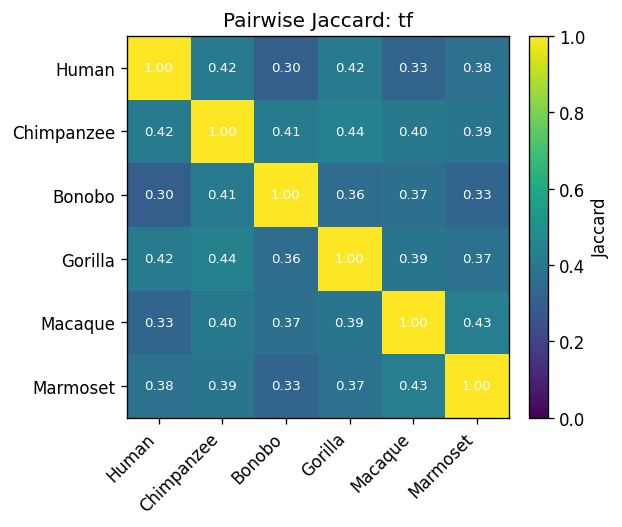

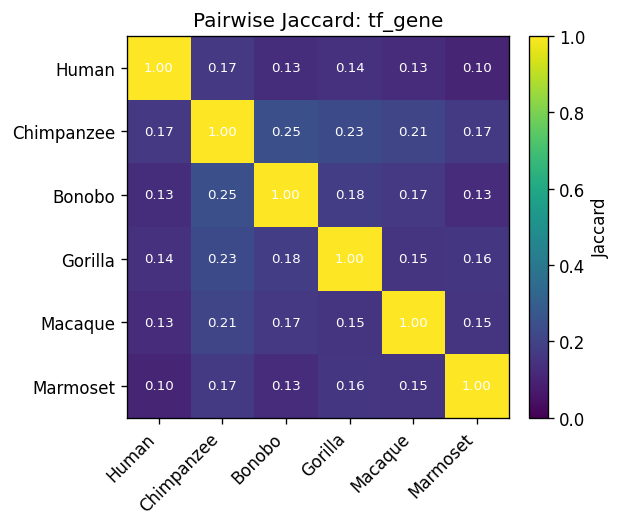

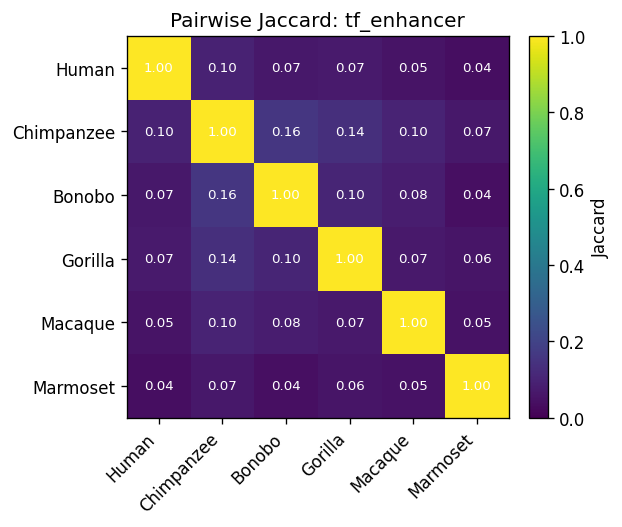

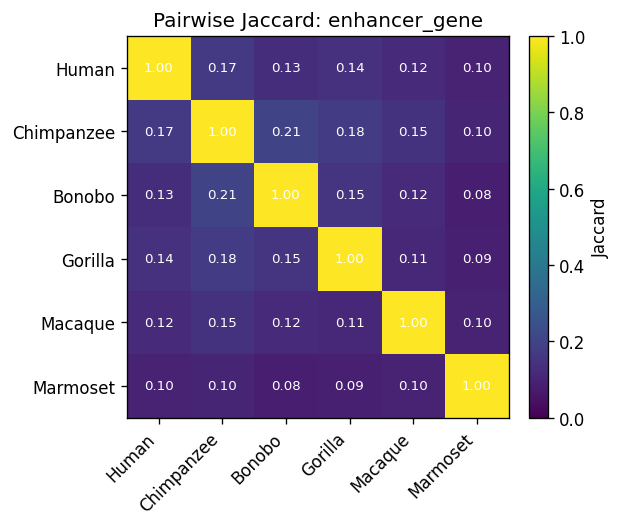

In [14]:
def pairwise_jaccard_matrix(consensus_sets: dict, key: str):
    species = sorted(consensus_sets.keys(), key=lambda x: (species_order.index(x) if x in species_order else 999, x))
    sets = {sp: consensus_sets[sp][key] for sp in species}
    mat = pd.DataFrame(index=species, columns=species, dtype=float)
    for a in species:
        for b in species:
            if a == b:
                mat.loc[a, b] = 1.0
                continue
            inter = len(sets[a] & sets[b])
            union = len(sets[a] | sets[b])
            mat.loc[a, b] = inter / union if union else np.nan
    return mat


for k in feature_keys:
    mat = pairwise_jaccard_matrix(cons_sets, k)
    fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=120)
    im = ax.imshow(mat.values, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))
    ax.set_xticklabels(mat.columns, rotation=45, ha='right')
    ax.set_yticklabels(mat.index)
    ax.set_title(f'Pairwise Jaccard: {k}')

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            txt = 'NA' if pd.isna(val) else f'{val:.2f}'
            ax.text(j, i, txt, ha='center', va='center', color='white', fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Jaccard')
    plt.tight_layout()
    plt.show()

## Optional: stricter consensus sensitivity check

Set `min_seed_support` to higher values (for example, half of seeds or all seeds) and re-run to inspect robustness.

In [15]:
example_min_support = max(1, int(np.floor(np.median(runs_df.groupby('species')['seed'].nunique()) / 2)))
strict_cons_sets = species_consensus_sets(ereg, min_seed_support=example_min_support)

summary_rows = []
for k in feature_keys:
    totals, present_k, conserved_all, pairwise = conservation_tables(strict_cons_sets, k)
    summary_rows.append({
        'feature': k,
        'min_seed_support': example_min_support,
        'conserved_in_all_species': conserved_all,
        'median_per_species': int(totals['n_elements'].median()),
    })

pd.DataFrame(summary_rows)

,feature,min_seed_support,conserved_in_all_species,median_per_species
0,tf,10,12,60
1,tf_gene,10,654,22983
2,tf_enhancer,10,487,58045
3,enhancer_gene,10,696,49708


## Seed-Level Stability And Conserved Regulon Series

This section adds:

- Species/seed run-level summaries:
  - number of regulons detected per run
  - average regulon size per run
  - number of regulons consistently detected across all seeds (within species)
- Conserved regulon series using TF-enhancer-target triplets detected in **X seeds** per species
  - default: `X = all seeds` for each species
- Species comparison of matched TFs and overlap percentages for:
  - TF-target gene links
  - TF-enhancer links
  - TF-to-other-TF links
- Highlighting:
  - human-specific TFs
  - human-aspecific TFs (present in all non-human species, absent in human)

Run-level summary (first rows):


,species,seed,n_regulons,mean_regulon_links,median_regulon_links,mean_regulon_targets,mean_regulon_enhancers,n_regulons_consistent_all_seeds
0,Bonobo,1,74,911.891892,482.5,390.500000,778.824324,48
1,Bonobo,2,77,866.077922,325.0,368.480519,734.805195,48
2,Bonobo,3,76,850.013158,320.5,361.473684,720.592105,48
3,Bonobo,4,79,870.835443,285.0,375.835443,736.632911,48
4,Bonobo,5,81,879.246914,256.0,383.308642,734.172840,48
5,Bonobo,6,74,911.702703,423.5,394.972973,776.500000,48
6,Bonobo,7,77,1078.896104,468.0,465.000000,903.350649,48
7,Bonobo,8,82,893.353659,311.5,385.536585,755.268293,48
8,Bonobo,9,83,852.987952,350.0,369.746988,722.638554,48
9,Bonobo,10,81,862.851852,355.0,366.753086,730.518519,48


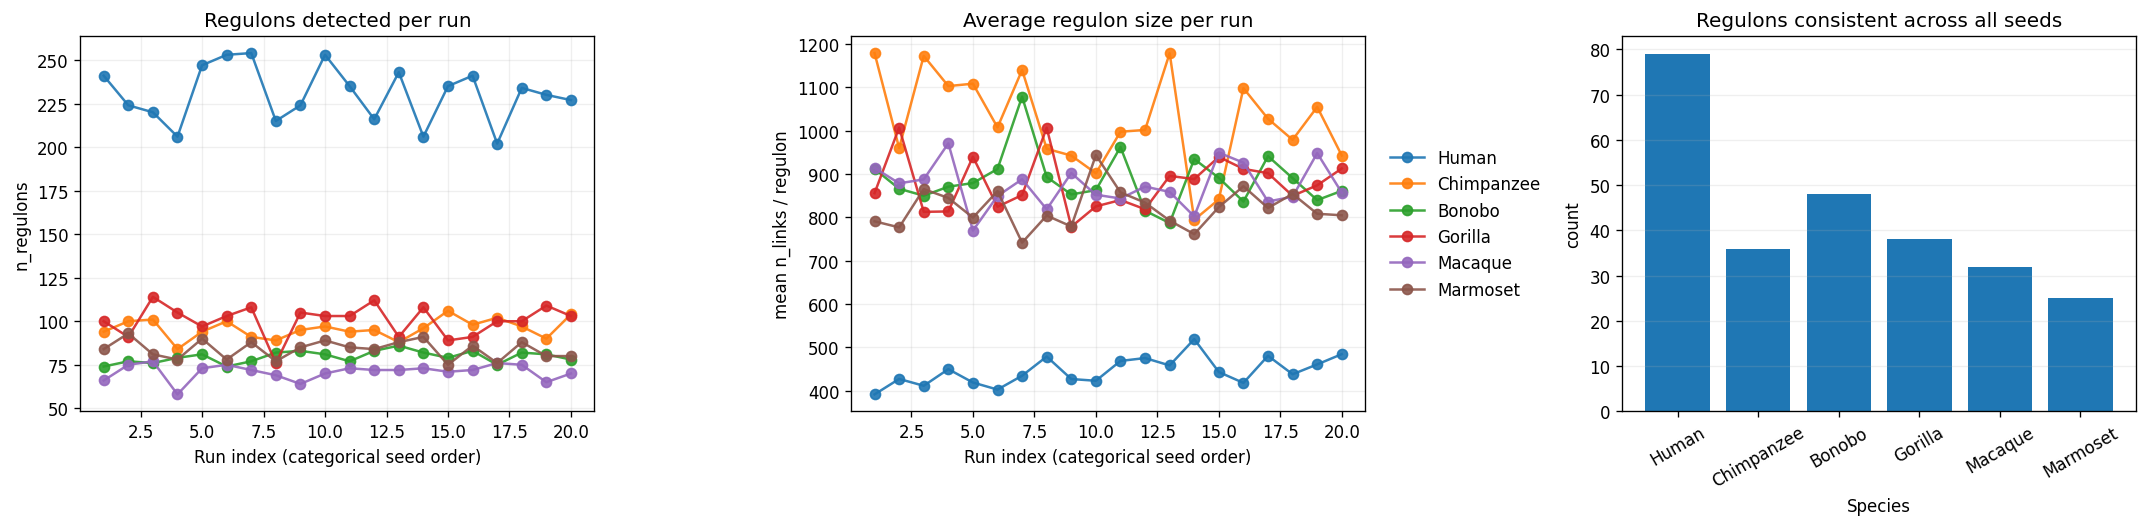

Conserved triplets per species (TF-enhancer-target):


,species,n_conserved_triplets
0,Bonobo,14508
1,Chimpanzee,11636
2,Gorilla,14275
3,Human,11640
4,Macaque,9025
5,Marmoset,9377


Pairwise shared TF counts (conserved series):


,Human,Chimpanzee,Bonobo,Gorilla,Macaque,Marmoset
Human,42.0,17.0,14.0,20.0,21.0,13.0
Chimpanzee,17.0,30.0,18.0,23.0,15.0,12.0
Bonobo,14.0,18.0,39.0,19.0,16.0,10.0
Gorilla,20.0,23.0,19.0,32.0,17.0,15.0
Macaque,21.0,15.0,16.0,17.0,27.0,13.0
Marmoset,13.0,12.0,10.0,15.0,13.0,21.0


Pairwise overlap summary (mean/std/count across shared TFs):


,species_pair,tf_target_overlap_pct_mean,tf_target_overlap_pct_std,tf_target_overlap_pct_count,tf_enhancer_overlap_pct_mean,tf_enhancer_overlap_pct_std,tf_enhancer_overlap_pct_count,tf_to_tf_overlap_pct_mean,tf_to_tf_overlap_pct_std,tf_to_tf_overlap_pct_count
0,Bonobo vs Gorilla,18.311318,12.713852,19,8.293201,6.846245,19,52.169312,39.607324,18
1,Bonobo vs Macaque,14.644390,7.222309,16,5.928540,3.006635,16,47.555556,32.402887,15
2,Bonobo vs Marmoset,10.675494,6.658071,10,3.543181,2.409872,10,44.444444,39.965263,9
3,Chimpanzee vs Bonobo,24.391730,10.414560,18,12.119627,6.876321,18,47.663690,27.932569,16
4,Chimpanzee vs Gorilla,18.102571,11.977927,23,10.314258,7.349425,23,42.997835,35.372946,22
5,Chimpanzee vs Macaque,16.147432,9.004157,15,6.418569,3.520704,15,45.119048,31.231588,14
6,Chimpanzee vs Marmoset,12.050218,7.532774,12,4.051214,2.744211,12,41.833333,37.765112,10
7,Gorilla vs Macaque,14.960489,8.579641,17,5.144605,2.841572,17,49.222222,38.816145,15
8,Gorilla vs Marmoset,11.006350,5.247747,15,3.652287,2.311645,15,45.119048,42.216699,14
9,Human vs Bonobo,14.283659,8.250873,14,5.980765,3.581876,14,30.128205,29.063003,13


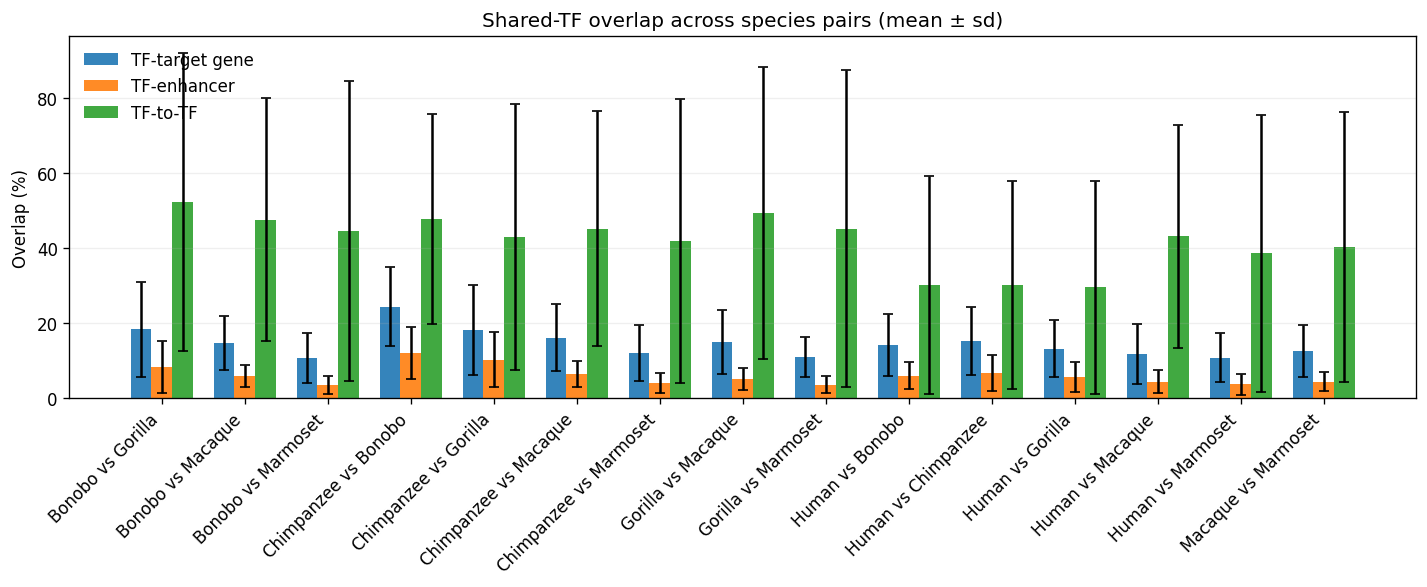

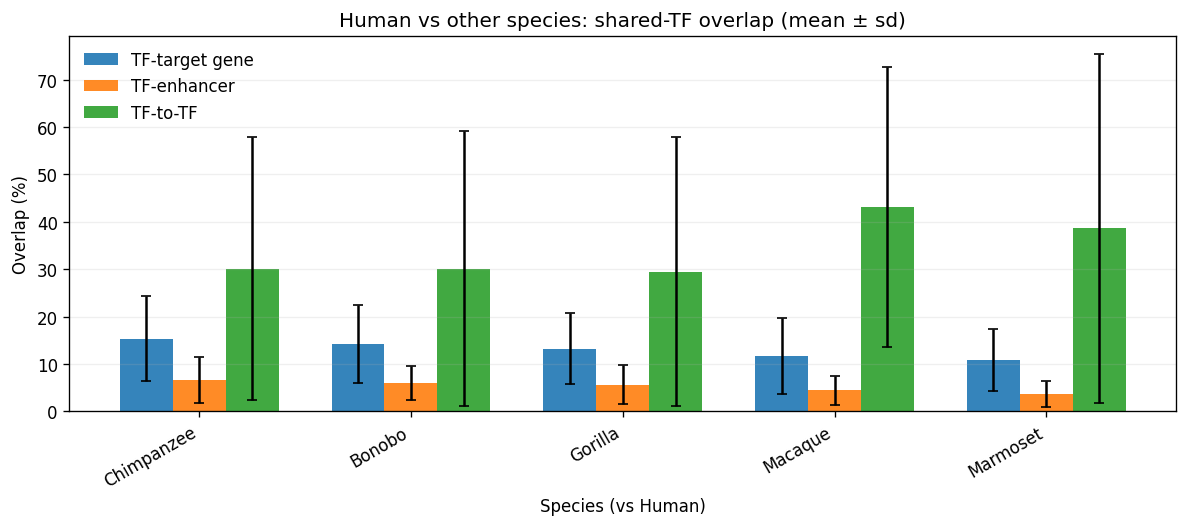

Human-specific TFs (15):
ATOH1, ELF3, FOS, FOSB, IRF4, MAF, MAFB, MEIS2, NFYC, PHF21A, RORA, SOX5, STAT4, TEAD1, ZEB1

Human-aspecific TFs (1):
TCF12


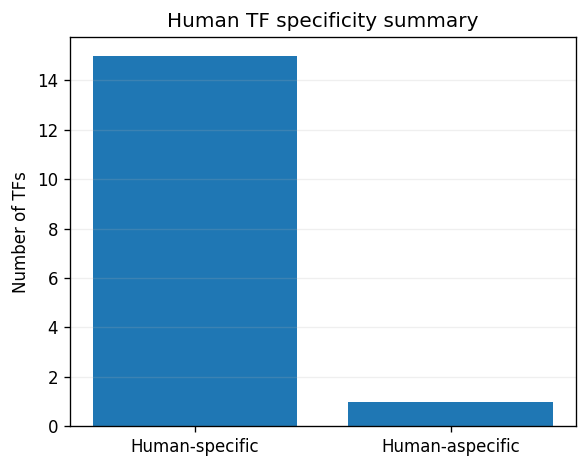

In [16]:
# ------------------------------
# Configuration
# ------------------------------
# Set X manually if needed. If None, X is interpreted as "all runs per species".
CONSERVATION_X_RUNS = None


# ------------------------------
# Build per-run regulon statistics
# ------------------------------
if 'peak_id' not in ereg.columns:
    raise RuntimeError('peak_id missing in ereg. Please run the enhancer-to-peak mapping cell first.')

triplet_cols = ['species', 'seed', 'TF', 'peak_id', 'Gene']
triplets = ereg[triplet_cols].dropna().drop_duplicates().copy()

regulon_run = (
    ereg.groupby(['species', 'seed', 'eRegulon_name'], as_index=False)
    .agg(
        n_links=('TF', 'size'),
        n_targets=('Gene', 'nunique'),
        n_enhancers=('peak_id', lambda x: x.dropna().nunique()),
        tf=('TF', 'first'),
    )
)

run_level = (
    regulon_run.groupby(['species', 'seed'], as_index=False)
    .agg(
        n_regulons=('eRegulon_name', 'nunique'),
        mean_regulon_links=('n_links', 'mean'),
        median_regulon_links=('n_links', 'median'),
        mean_regulon_targets=('n_targets', 'mean'),
        mean_regulon_enhancers=('n_enhancers', 'mean'),
    )
)

# Regulons consistently detected across all seeds per species
reg_presence = (
    ereg[['species', 'seed', 'eRegulon_name']]
    .drop_duplicates()
    .groupby(['species', 'eRegulon_name'])['seed']
    .nunique()
    .rename('seed_support')
    .reset_index()
)

n_seeds_by_species = runs_df.groupby('species')['seed'].nunique().rename('n_seeds').reset_index()
reg_presence = reg_presence.merge(n_seeds_by_species, on='species', how='left')
consistent_regulons = (
    reg_presence.loc[reg_presence['seed_support'] == reg_presence['n_seeds']]
    .groupby('species')
    .size()
    .rename('n_regulons_consistent_all_seeds')
    .reset_index()
)

run_level_with_consistency = run_level.merge(consistent_regulons, on='species', how='left').fillna(0)
run_level_with_consistency['n_regulons_consistent_all_seeds'] = run_level_with_consistency['n_regulons_consistent_all_seeds'].astype(int)

print('Run-level summary (first rows):')
display(run_level_with_consistency.head(12))


# ------------------------------
# Species/seed plots
# ------------------------------
ordered_species = [s for s in species_order if s in run_level_with_consistency['species'].unique()]

# Make seeds categorical/equally spaced by plotting seed rank per species.
run_level_plot = run_level_with_consistency.sort_values(['species', 'seed']).copy()
run_level_plot['seed_rank'] = run_level_plot.groupby('species').cumcount() + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=120)

for sp in ordered_species:
    tmp = run_level_plot.loc[run_level_plot['species'] == sp].sort_values('seed_rank')
    axes[0].plot(tmp['seed_rank'], tmp['n_regulons'], marker='o', label=sp, alpha=0.9)
axes[0].set_title('Regulons detected per run')
axes[0].set_xlabel('Run index (categorical seed order)')
axes[0].set_ylabel('n_regulons')
axes[0].grid(alpha=0.2)

for sp in ordered_species:
    tmp = run_level_plot.loc[run_level_plot['species'] == sp].sort_values('seed_rank')
    axes[1].plot(tmp['seed_rank'], tmp['mean_regulon_links'], marker='o', label=sp, alpha=0.9)
axes[1].set_title('Average regulon size per run')
axes[1].set_xlabel('Run index (categorical seed order)')
axes[1].set_ylabel('mean n_links / regulon')
axes[1].grid(alpha=0.2)

cons_counts = (
    run_level_with_consistency[['species', 'n_regulons_consistent_all_seeds']]
    .drop_duplicates()
    .set_index('species')
    .reindex(ordered_species)
)
axes[2].bar(cons_counts.index, cons_counts['n_regulons_consistent_all_seeds'])
axes[2].set_title('Regulons consistent across all seeds')
axes[2].set_xlabel('Species')
axes[2].set_ylabel('count')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(alpha=0.2, axis='y')

axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()


# ------------------------------
# Conserved regulon series (TF-enhancer-target) with seed threshold X
# ------------------------------
def get_seed_threshold(species: str, n_seeds: int, x_runs: int | None) -> int:
    if x_runs is None:
        return n_seeds
    return max(1, min(int(x_runs), int(n_seeds)))

triplet_support = (
    triplets.groupby(['species', 'TF', 'peak_id', 'Gene'])['seed']
    .nunique()
    .rename('seed_support')
    .reset_index()
)

triplet_support = triplet_support.merge(n_seeds_by_species, on='species', how='left')
triplet_support['required_support'] = triplet_support.apply(
    lambda r: get_seed_threshold(r['species'], r['n_seeds'], CONSERVATION_X_RUNS),
    axis=1,
)

conserved_triplets = triplet_support.loc[
    triplet_support['seed_support'] >= triplet_support['required_support']
].copy()

print('Conserved triplets per species (TF-enhancer-target):')
display(conserved_triplets.groupby('species').size().rename('n_conserved_triplets').reset_index())


# ------------------------------
# Build per-species TF link dictionaries from conserved triplets
# ------------------------------
all_species = sorted(conserved_triplets['species'].unique(), key=lambda x: (species_order.index(x) if x in species_order else 999, x))

tfs_by_species = {
    sp: set(conserved_triplets.loc[conserved_triplets['species'] == sp, 'TF'].unique())
    for sp in all_species
}

tf_targets_by_species = {}
tf_enhancers_by_species = {}

for sp in all_species:
    sp_df = conserved_triplets.loc[conserved_triplets['species'] == sp]
    tf_targets_by_species[sp] = {
        tf: set(g['Gene'].unique())
        for tf, g in sp_df.groupby('TF')
    }
    tf_enhancers_by_species[sp] = {
        tf: set(g['peak_id'].dropna().unique())
        for tf, g in sp_df.groupby('TF')
    }


# ------------------------------
# How many TFs match across species (pairwise matrix)
# ------------------------------
shared_tf_mat = pd.DataFrame(index=all_species, columns=all_species, dtype=int)
for a in all_species:
    for b in all_species:
        shared_tf_mat.loc[a, b] = len(tfs_by_species[a] & tfs_by_species[b])

print('Pairwise shared TF counts (conserved series):')
display(shared_tf_mat)


# ------------------------------
# Pairwise overlap percentages for shared TFs
# TF-target, TF-enhancer, TF->other-TF (target in shared TF set)
# ------------------------------
def jaccard_pct(a_set: set, b_set: set) -> float:
    u = a_set | b_set
    if not u:
        return np.nan
    return 100.0 * len(a_set & b_set) / len(u)

pair_tf_rows = []
for a, b in combinations(all_species, 2):
    shared_tfs = sorted(tfs_by_species[a] & tfs_by_species[b])
    for tf in shared_tfs:
        tg_a = tf_targets_by_species[a].get(tf, set())
        tg_b = tf_targets_by_species[b].get(tf, set())

        te_a = tf_enhancers_by_species[a].get(tf, set())
        te_b = tf_enhancers_by_species[b].get(tf, set())

        # TF->TF links: restrict target genes to TF universe shared by this species pair
        tf_universe_pair = tfs_by_species[a] & tfs_by_species[b]
        tftf_a = tg_a & tf_universe_pair
        tftf_b = tg_b & tf_universe_pair

        pair_tf_rows.append({
            'species_a': a,
            'species_b': b,
            'species_pair': f'{a} vs {b}',
            'TF': tf,
            'tf_target_overlap_pct': jaccard_pct(tg_a, tg_b),
            'tf_enhancer_overlap_pct': jaccard_pct(te_a, te_b),
            'tf_to_tf_overlap_pct': jaccard_pct(tftf_a, tftf_b),
        })

pair_tf_overlap = pd.DataFrame(pair_tf_rows)

if pair_tf_overlap.empty:
    print('No shared TFs available across species under current conserved-series threshold.')
else:
    metric_cols = ['tf_target_overlap_pct', 'tf_enhancer_overlap_pct', 'tf_to_tf_overlap_pct']

    pair_metric_summary = (
        pair_tf_overlap.groupby('species_pair')[metric_cols]
        .agg(['mean', 'std', 'count'])
    )
    # Flatten multi-index columns
    pair_metric_summary.columns = ['_'.join(c).strip('_') for c in pair_metric_summary.columns]
    pair_metric_summary = pair_metric_summary.reset_index()

    print('Pairwise overlap summary (mean/std/count across shared TFs):')
    display(pair_metric_summary)

    # Build barplots with error bars (std)
    plot_df = pair_tf_overlap.melt(
        id_vars=['species_pair', 'TF'],
        value_vars=metric_cols,
        var_name='metric',
        value_name='overlap_pct',
    )

    metric_labels = {
        'tf_target_overlap_pct': 'TF-target gene',
        'tf_enhancer_overlap_pct': 'TF-enhancer',
        'tf_to_tf_overlap_pct': 'TF-to-TF',
    }
    plot_df['metric_label'] = plot_df['metric'].map(metric_labels)

    bar_stats = (
        plot_df.groupby(['species_pair', 'metric_label'])['overlap_pct']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )

    pair_order = bar_stats['species_pair'].drop_duplicates().tolist()
    metric_order = ['TF-target gene', 'TF-enhancer', 'TF-to-TF']

    x = np.arange(len(pair_order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(12, len(pair_order) * 0.7), 5), dpi=120)
    for i, m in enumerate(metric_order):
        sub = bar_stats.loc[bar_stats['metric_label'] == m].set_index('species_pair').reindex(pair_order)
        means = sub['mean'].to_numpy(dtype=float)
        errs = sub['std'].fillna(0).to_numpy(dtype=float)
        ax.bar(x + (i - 1) * width, means, width=width, yerr=errs, capsize=3, label=m, alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(pair_order, rotation=45, ha='right')
    ax.set_ylabel('Overlap (%)')
    ax.set_title('Shared-TF overlap across species pairs (mean ± sd)')
    ax.grid(axis='y', alpha=0.2)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Human vs all other species only
    human_plot_df = pair_tf_overlap.loc[
        (pair_tf_overlap['species_a'] == 'Human') | (pair_tf_overlap['species_b'] == 'Human')
    ].copy()

    if not human_plot_df.empty:
        human_plot_df['other_species'] = np.where(
            human_plot_df['species_a'] == 'Human',
            human_plot_df['species_b'],
            human_plot_df['species_a'],
        )

        human_melt = human_plot_df.melt(
            id_vars=['other_species', 'TF'],
            value_vars=metric_cols,
            var_name='metric',
            value_name='overlap_pct',
        )
        human_melt['metric_label'] = human_melt['metric'].map(metric_labels)

        human_stats = (
            human_melt.groupby(['other_species', 'metric_label'])['overlap_pct']
            .agg(['mean', 'std', 'count'])
            .reset_index()
        )

        other_order = [s for s in species_order if s in human_stats['other_species'].unique() and s != 'Human']
        metric_order = ['TF-target gene', 'TF-enhancer', 'TF-to-TF']

        x = np.arange(len(other_order))
        width = 0.25

        fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
        for i, m in enumerate(metric_order):
            sub = human_stats.loc[human_stats['metric_label'] == m].set_index('other_species').reindex(other_order)
            means = sub['mean'].to_numpy(dtype=float)
            errs = sub['std'].fillna(0).to_numpy(dtype=float)
            ax.bar(x + (i - 1) * width, means, width=width, yerr=errs, capsize=3, label=m, alpha=0.9)

        ax.set_xticks(x)
        ax.set_xticklabels(other_order, rotation=30, ha='right')
        ax.set_ylabel('Overlap (%)')
        ax.set_xlabel('Species (vs Human)')
        ax.set_title('Human vs other species: shared-TF overlap (mean ± sd)')
        ax.grid(axis='y', alpha=0.2)
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show()


# ------------------------------
# Human-specific and human-aspecific TFs
# ------------------------------
if 'Human' in tfs_by_species:
    human_tfs = tfs_by_species['Human']
    non_human_species = [sp for sp in all_species if sp != 'Human']

    non_human_union = set().union(*[tfs_by_species[s] for s in non_human_species]) if non_human_species else set()
    human_specific_tfs = sorted(human_tfs - non_human_union)

    if non_human_species:
        non_human_intersection = set.intersection(*[tfs_by_species[s] for s in non_human_species])
    else:
        non_human_intersection = set()
    human_aspecific_tfs = sorted(non_human_intersection - human_tfs)

    print(f'Human-specific TFs ({len(human_specific_tfs)}):')
    print(', '.join(human_specific_tfs[:200]) if human_specific_tfs else 'None')

    print(f'\nHuman-aspecific TFs ({len(human_aspecific_tfs)}):')
    print(', '.join(human_aspecific_tfs[:200]) if human_aspecific_tfs else 'None')

    fig, ax = plt.subplots(figsize=(5, 4), dpi=120)
    ax.bar(['Human-specific', 'Human-aspecific'], [len(human_specific_tfs), len(human_aspecific_tfs)])
    ax.set_ylabel('Number of TFs')
    ax.set_title('Human TF specificity summary')
    ax.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('Human not found in conserved triplet species set.')

## Strict Human-Specific TFs And Conservation Ranking Plots

This section adds:

- **Strict** human-specific TFs: present in Human and absent from **all seed runs** of every other species.
- Strict human-aspecific TFs: present in all other species (any seed run) and absent in Human.
- Ranking scatter plots for Human TF conservation (two styles):
  - Human vs all non-human species
  - Human vs great apes only (Chimpanzee, Bonobo, Gorilla)

For each style, three ranked scatter plots are shown:

1. Average % conservation of target genes
2. Average % conservation of enhancers
3. Average % conservation of enhancer-target pairs (both)

FOXP2 is highlighted in red if present.

Strict Human-specific TFs (pass Human filtering AND absent from all other species across any seed) [2]:
MAFB, TEAD1

Strict Human-aspecific TFs (present in all other species across any seed, absent in Human) [3]:
MEIS1, NFAT5, NFKB1


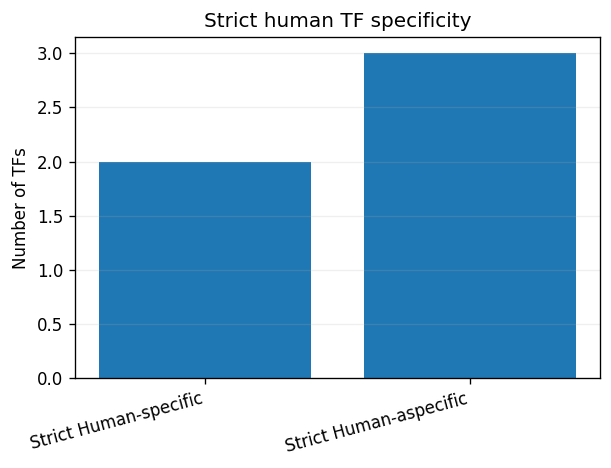

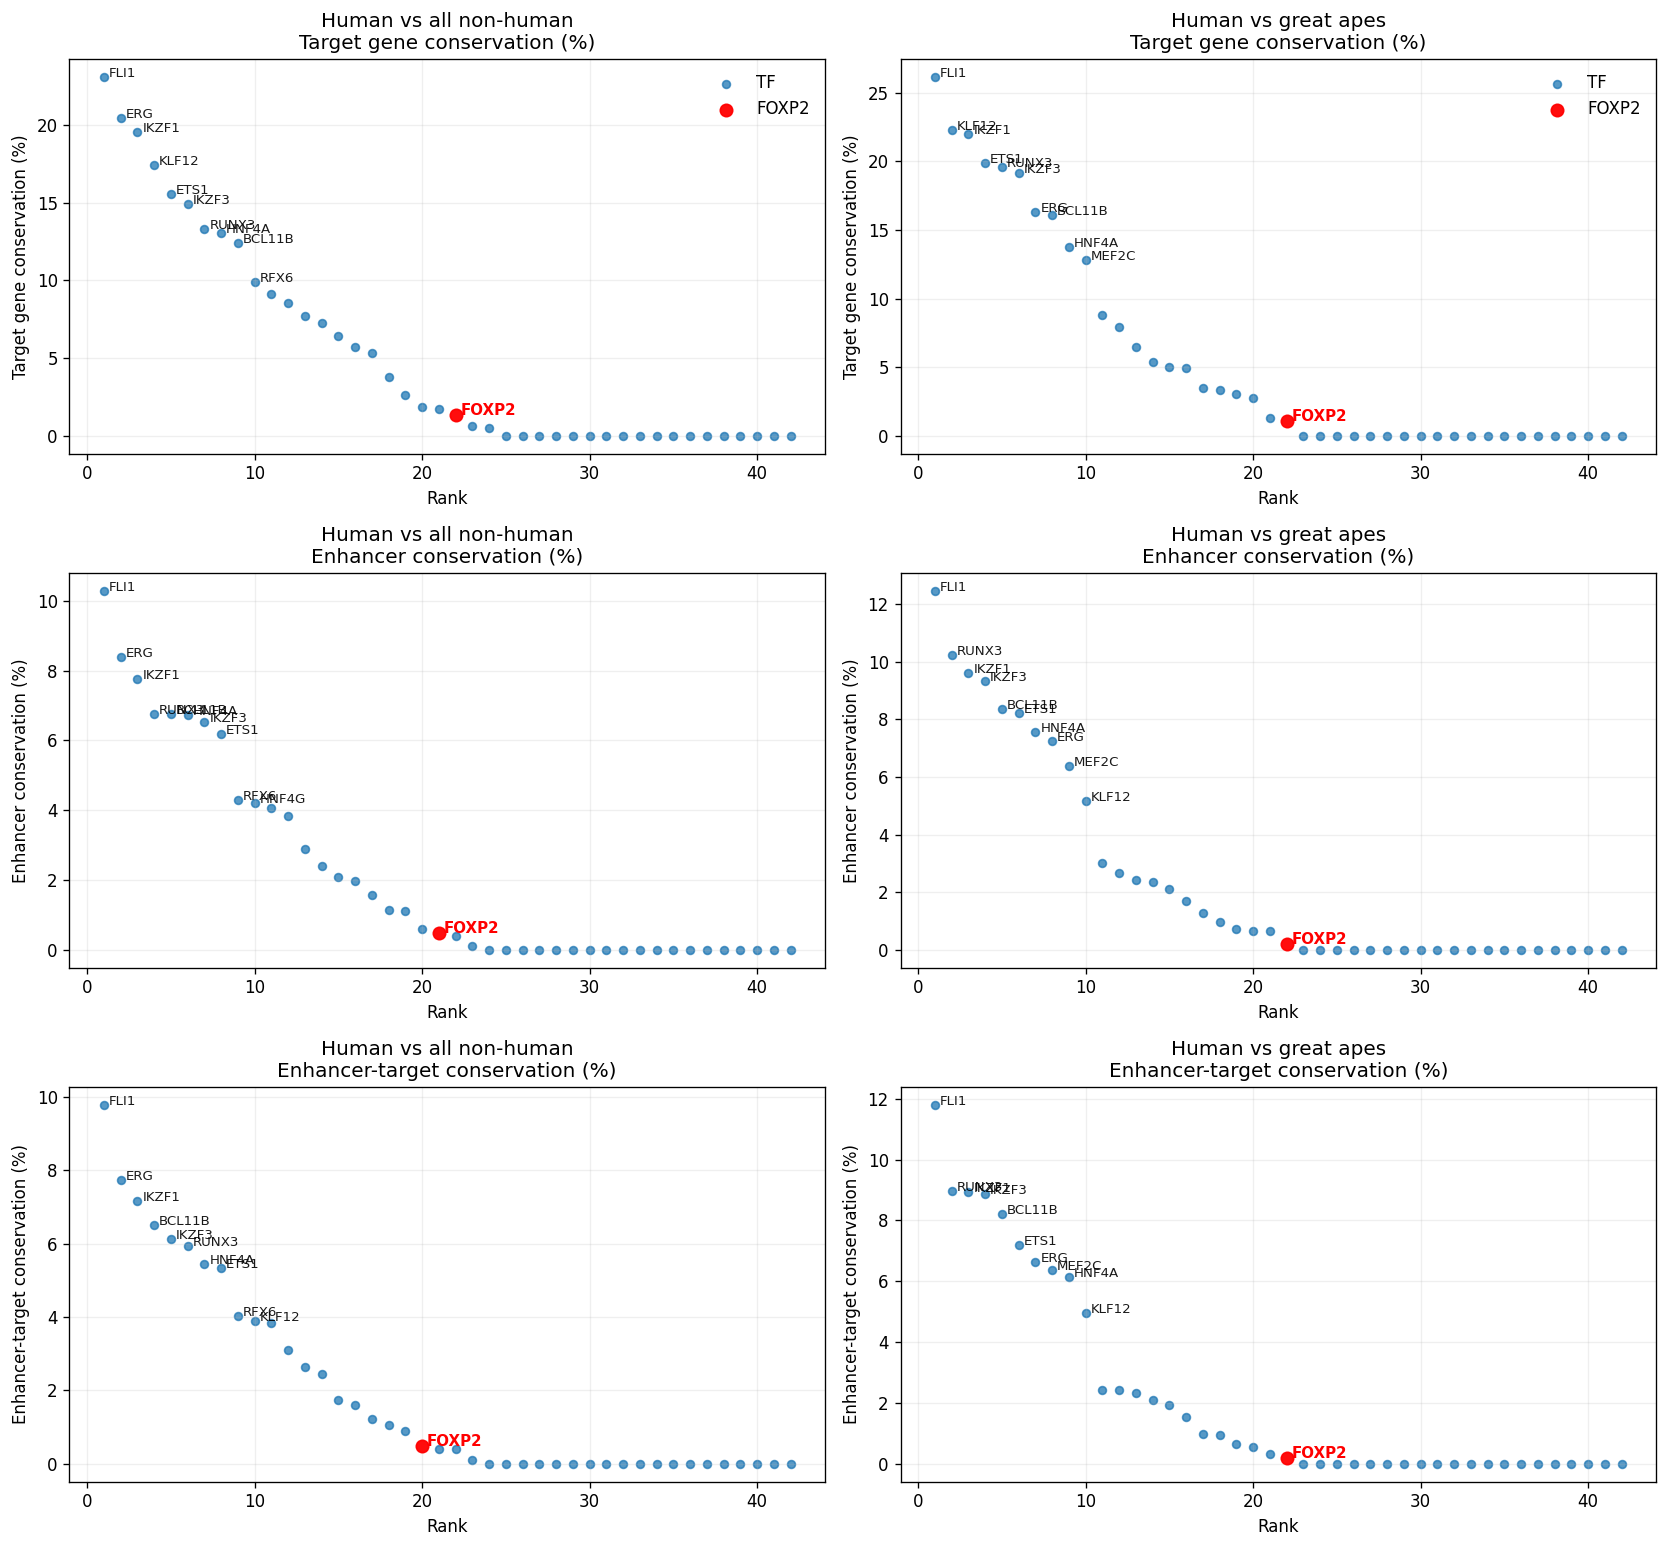

Top TFs by conservation metric and style:

Human vs all non-human

Top 10 - Target gene conservation (%)


,TF,avg_target_conservation_pct
0,FLI1,23.089366
1,ERG,20.441450
2,IKZF1,19.527932
3,KLF12,17.405850
4,ETS1,15.532462
5,IKZF3,14.935272
6,RUNX3,13.331313
7,HNF4A,13.073945
8,BCL11B,12.396899
9,RFX6,9.873672



Top 10 - Enhancer conservation (%)


,TF,avg_enhancer_conservation_pct
0,FLI1,10.279820
1,ERG,8.380588
2,IKZF1,7.758159
3,RUNX3,6.753613
4,BCL11B,6.750837
5,HNF4A,6.730323
6,IKZF3,6.515725
7,ETS1,6.189249
8,RFX6,4.287915
9,HNF4G,4.198850



Top 10 - Enhancer-target conservation (%)


...

,TF,avg_target_conservation_pct
0,FLI1,26.158790
1,KLF12,22.290382
2,IKZF1,21.994032
3,ETS1,19.917287
4,RUNX3,19.573352
5,IKZF3,19.186415
6,ERG,16.276085
7,BCL11B,16.063797
8,HNF4A,13.749189
9,MEF2C,12.834676



Top 10 - Enhancer conservation (%)


,TF,avg_enhancer_conservation_pct
0,FLI1,12.462355
1,RUNX3,10.225093
2,IKZF1,9.613698
3,IKZF3,9.321079
4,BCL11B,8.377832
5,ETS1,8.235904
6,HNF4A,7.571927
7,ERG,7.258167
8,MEF2C,6.397942
9,KLF12,5.178164



Top 10 - Enhancer-target conservation (%)


,TF,avg_both_conservation_pct
0,FLI1,11.797664
1,RUNX3,8.962591
2,IKZF1,8.945492
3,IKZF3,8.881598
4,BCL11B,8.222713
5,ETS1,7.177771
6,ERG,6.641803
7,MEF2C,6.379422
8,HNF4A,6.132076
9,KLF12,4.944090


In [17]:
# ------------------------------
# Strict human-specific/aspecific definitions
# ------------------------------
# Requirement:
# - Human-specific TFs must PASS filtering in Human (conserved_triplets)
# - and be absent from ALL other species across ANY seed run.
if 'conserved_triplets' not in globals():
    raise RuntimeError('conserved_triplets not available. Run the previous section first.')

# TFs that pass filtering in Human (from conserved triplets)
human_passed_tfs = set(
    conserved_triplets.loc[conserved_triplets['species'] == 'Human', 'TF'].dropna().unique()
)
if not human_passed_tfs:
    raise RuntimeError('No Human TFs pass filtering in conserved_triplets under current threshold.')

# TF detection across ANY seed in each species (raw detection universe)
tf_anyseed_by_species = {
    sp: set(g['TF'].dropna().unique())
    for sp, g in ereg.groupby('species')
}
if 'Human' not in tf_anyseed_by_species:
    raise RuntimeError('Human not found in ereg species.')

other_species_anyseed = [sp for sp in sorted(tf_anyseed_by_species.keys()) if sp != 'Human']
other_union_anyseed = set().union(*[tf_anyseed_by_species[s] for s in other_species_anyseed]) if other_species_anyseed else set()

# Final strict definition requested by user
strict_human_specific_tfs = sorted(human_passed_tfs - other_union_anyseed)

# Keep strict human-aspecific as: present in all non-human species (any seed), absent in Human (any seed)
human_anyseed_tfs = tf_anyseed_by_species['Human']
if other_species_anyseed:
    other_intersection_anyseed = set.intersection(*[tf_anyseed_by_species[s] for s in other_species_anyseed])
else:
    other_intersection_anyseed = set()
strict_human_aspecific_tfs = sorted(other_intersection_anyseed - human_anyseed_tfs)

print(
    f'Strict Human-specific TFs (pass Human filtering AND absent from all other species across any seed) '
    f'[{len(strict_human_specific_tfs)}]:'
)
print(', '.join(strict_human_specific_tfs[:300]) if strict_human_specific_tfs else 'None')

print(
    f'\nStrict Human-aspecific TFs (present in all other species across any seed, absent in Human) '
    f'[{len(strict_human_aspecific_tfs)}]:'
)
print(', '.join(strict_human_aspecific_tfs[:300]) if strict_human_aspecific_tfs else 'None')

fig, ax = plt.subplots(figsize=(5.2, 4), dpi=120)
ax.bar(['Strict Human-specific', 'Strict Human-aspecific'], [len(strict_human_specific_tfs), len(strict_human_aspecific_tfs)])
ax.set_ylabel('Number of TFs')
ax.set_title('Strict human TF specificity')
ax.grid(axis='y', alpha=0.2)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


# ------------------------------
# Ranking scatter plots for conservation
# ------------------------------
def jaccard_percent(a: set, b: set) -> float:
    u = a | b
    if not u:
        return 0.0
    return 100.0 * len(a & b) / len(u)

# Build TF -> sets per species
sp_tf_targets = {}
sp_tf_enhancers = {}
sp_tf_pairs = {}

for sp, sp_df in conserved_triplets.groupby('species'):
    sp_tf_targets[sp] = {tf: set(g['Gene'].astype(str).unique()) for tf, g in sp_df.groupby('TF')}
    sp_tf_enhancers[sp] = {tf: set(g['peak_id'].astype(str).unique()) for tf, g in sp_df.groupby('TF')}
    sp_tf_pairs[sp] = {
        tf: set(zip(g['peak_id'].astype(str), g['Gene'].astype(str)))
        for tf, g in sp_df.groupby('TF')
    }

human_tfs_conserved = set(sp_tf_targets.get('Human', {}).keys())
if not human_tfs_conserved:
    raise RuntimeError('No Human TFs in conserved_triplets under current threshold.')

comparison_styles = {
    'Human vs all non-human': [s for s in species_order if s != 'Human' and s in sp_tf_targets],
    'Human vs great apes': [s for s in ['Chimpanzee', 'Bonobo', 'Gorilla'] if s in sp_tf_targets],
}

rows = []
for style_name, comp_species in comparison_styles.items():
    if not comp_species:
        continue

    for tf in sorted(human_tfs_conserved):
        target_scores = []
        enhancer_scores = []
        both_scores = []

        h_tg = sp_tf_targets['Human'].get(tf, set())
        h_en = sp_tf_enhancers['Human'].get(tf, set())
        h_both = sp_tf_pairs['Human'].get(tf, set())

        for sp in comp_species:
            s_tg = sp_tf_targets.get(sp, {}).get(tf, set())
            s_en = sp_tf_enhancers.get(sp, {}).get(tf, set())
            s_both = sp_tf_pairs.get(sp, {}).get(tf, set())

            target_scores.append(jaccard_percent(h_tg, s_tg))
            enhancer_scores.append(jaccard_percent(h_en, s_en))
            both_scores.append(jaccard_percent(h_both, s_both))

        rows.append({
            'style': style_name,
            'TF': tf,
            'avg_target_conservation_pct': float(np.mean(target_scores)),
            'avg_enhancer_conservation_pct': float(np.mean(enhancer_scores)),
            'avg_both_conservation_pct': float(np.mean(both_scores)),
        })

rank_df = pd.DataFrame(rows)

metric_specs = [
    ('avg_target_conservation_pct', 'Target gene conservation (%)'),
    ('avg_enhancer_conservation_pct', 'Enhancer conservation (%)'),
    ('avg_both_conservation_pct', 'Enhancer-target conservation (%)'),
]

styles_available = [s for s in ['Human vs all non-human', 'Human vs great apes'] if s in rank_df['style'].unique()]
if not styles_available:
    raise RuntimeError('No ranking styles available to plot.')

fig, axes = plt.subplots(
    nrows=3,
    ncols=len(styles_available),
    figsize=(7 * len(styles_available), 13),
    dpi=120,
    squeeze=False,
)

TOP_LABELS = 10

for col_i, style_name in enumerate(styles_available):
    sub_style = rank_df.loc[rank_df['style'] == style_name].copy()

    for row_i, (metric_col, y_label) in enumerate(metric_specs):
        ax = axes[row_i, col_i]
        plot_df = sub_style.sort_values(metric_col, ascending=False).reset_index(drop=True)
        plot_df['rank'] = np.arange(1, len(plot_df) + 1)

        is_foxp2 = plot_df['TF'].str.upper().eq('FOXP2')

        ax.scatter(
            plot_df.loc[~is_foxp2, 'rank'],
            plot_df.loc[~is_foxp2, metric_col],
            s=22,
            alpha=0.75,
            color='#1f77b4',
            label='TF',
        )

        if is_foxp2.any():
            ax.scatter(
                plot_df.loc[is_foxp2, 'rank'],
                plot_df.loc[is_foxp2, metric_col],
                s=55,
                alpha=0.95,
                color='red',
                label='FOXP2',
                zorder=5,
            )

        to_label = plot_df.head(TOP_LABELS)
        for r in to_label.itertuples(index=False):
            ax.text(r.rank + 0.3, getattr(r, metric_col), r.TF, fontsize=8, alpha=0.9)

        # Ensure FOXP2 is always labeled if present
        if is_foxp2.any():
            fox = plot_df.loc[is_foxp2].iloc[0]
            ax.text(fox['rank'] + 0.3, fox[metric_col], 'FOXP2', fontsize=9, color='red', weight='bold')

        ax.set_xlabel('Rank')
        ax.set_ylabel(y_label)
        ax.set_title(f'{style_name}\n{y_label}')
        ax.grid(alpha=0.2)

        if row_i == 0:
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                uniq = dict(zip(labels, handles))
                ax.legend(uniq.values(), uniq.keys(), frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

print('Top TFs by conservation metric and style:')
for style_name in styles_available:
    print('\n' + '=' * 80)
    print(style_name)
    sub_style = rank_df.loc[rank_df['style'] == style_name]
    for metric_col, y_label in metric_specs:
        top = sub_style.sort_values(metric_col, ascending=False).head(10)[['TF', metric_col]]
        print(f'\nTop 10 - {y_label}')
        display(top.reset_index(drop=True))

## Publication-Style Figure Export (PNG + Editable-Text PDF)

This section regenerates the key figures in publication style and saves them as:

- `*.png` (high resolution)
- `*.pdf` (editable text via matplotlib PDF font settings)

Output directory:

- `/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication`

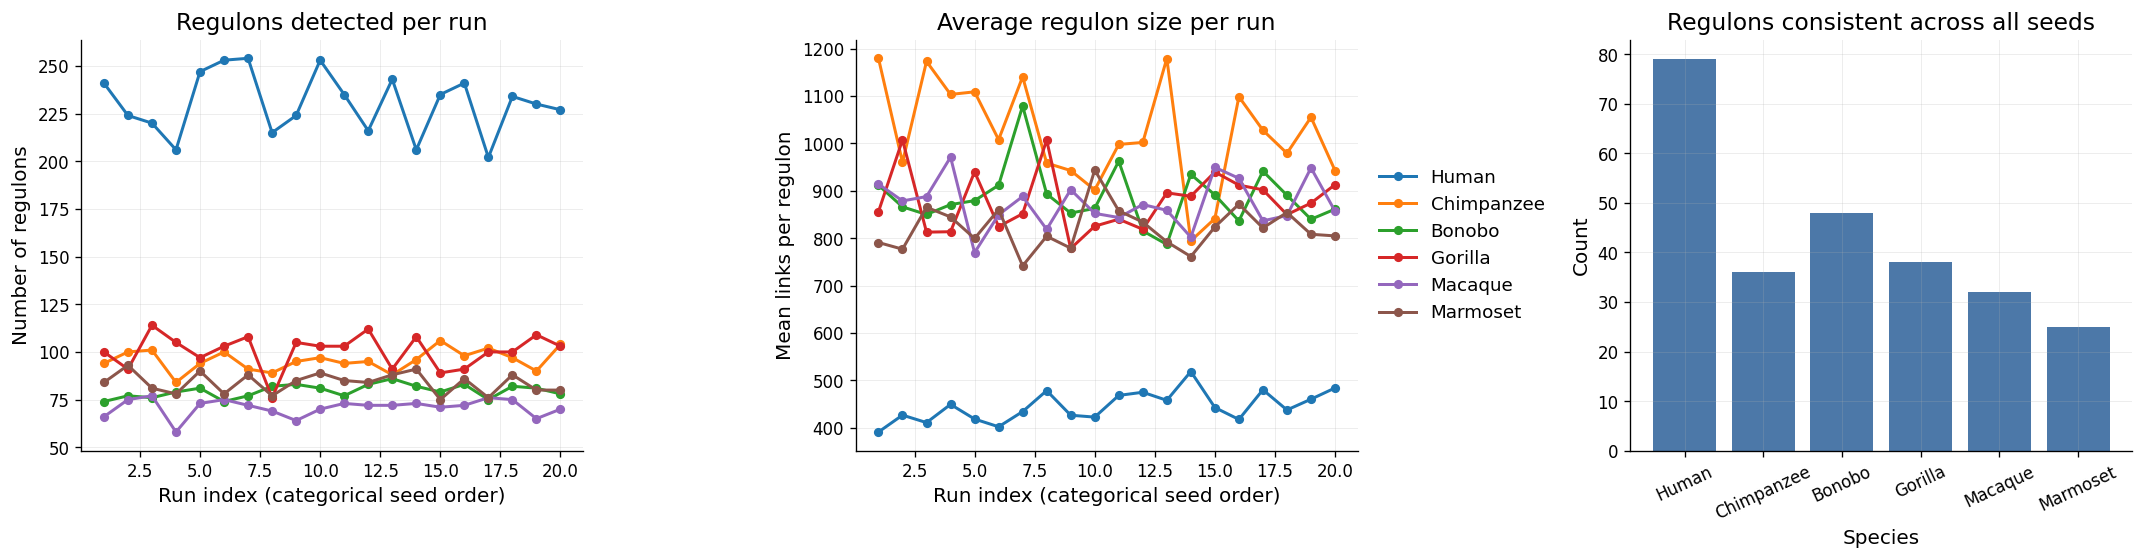

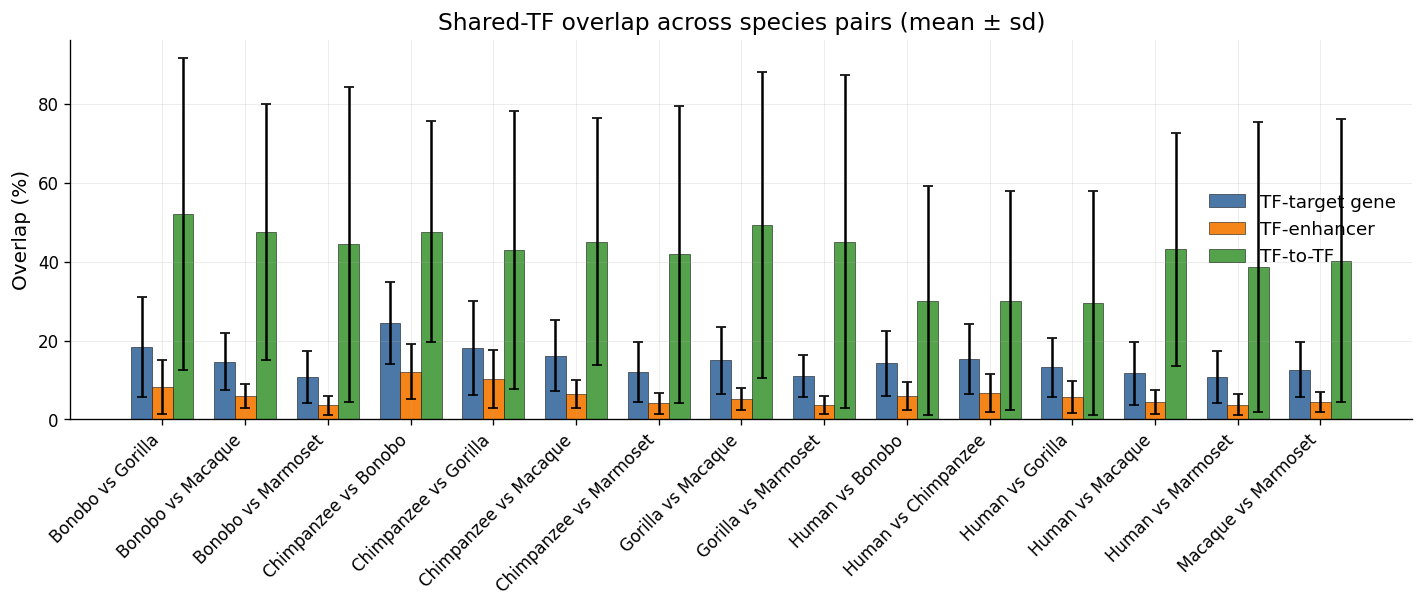

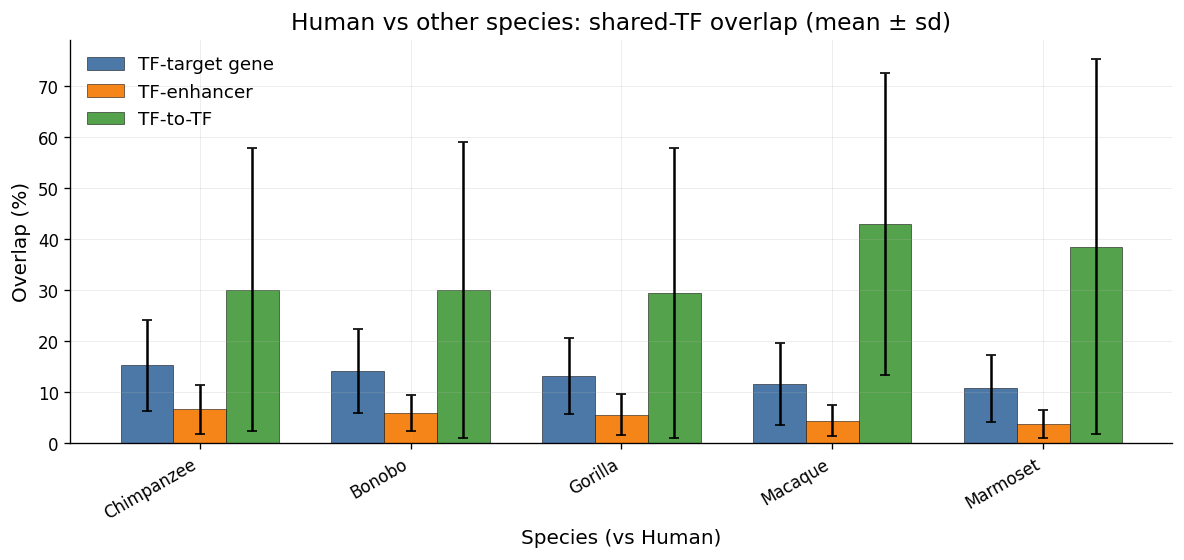

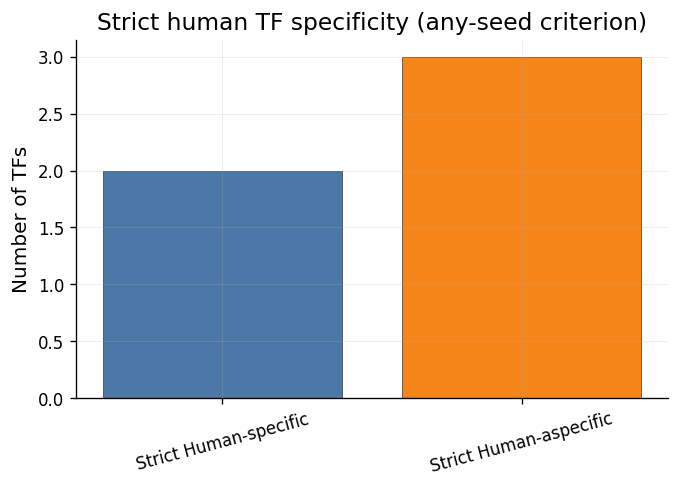

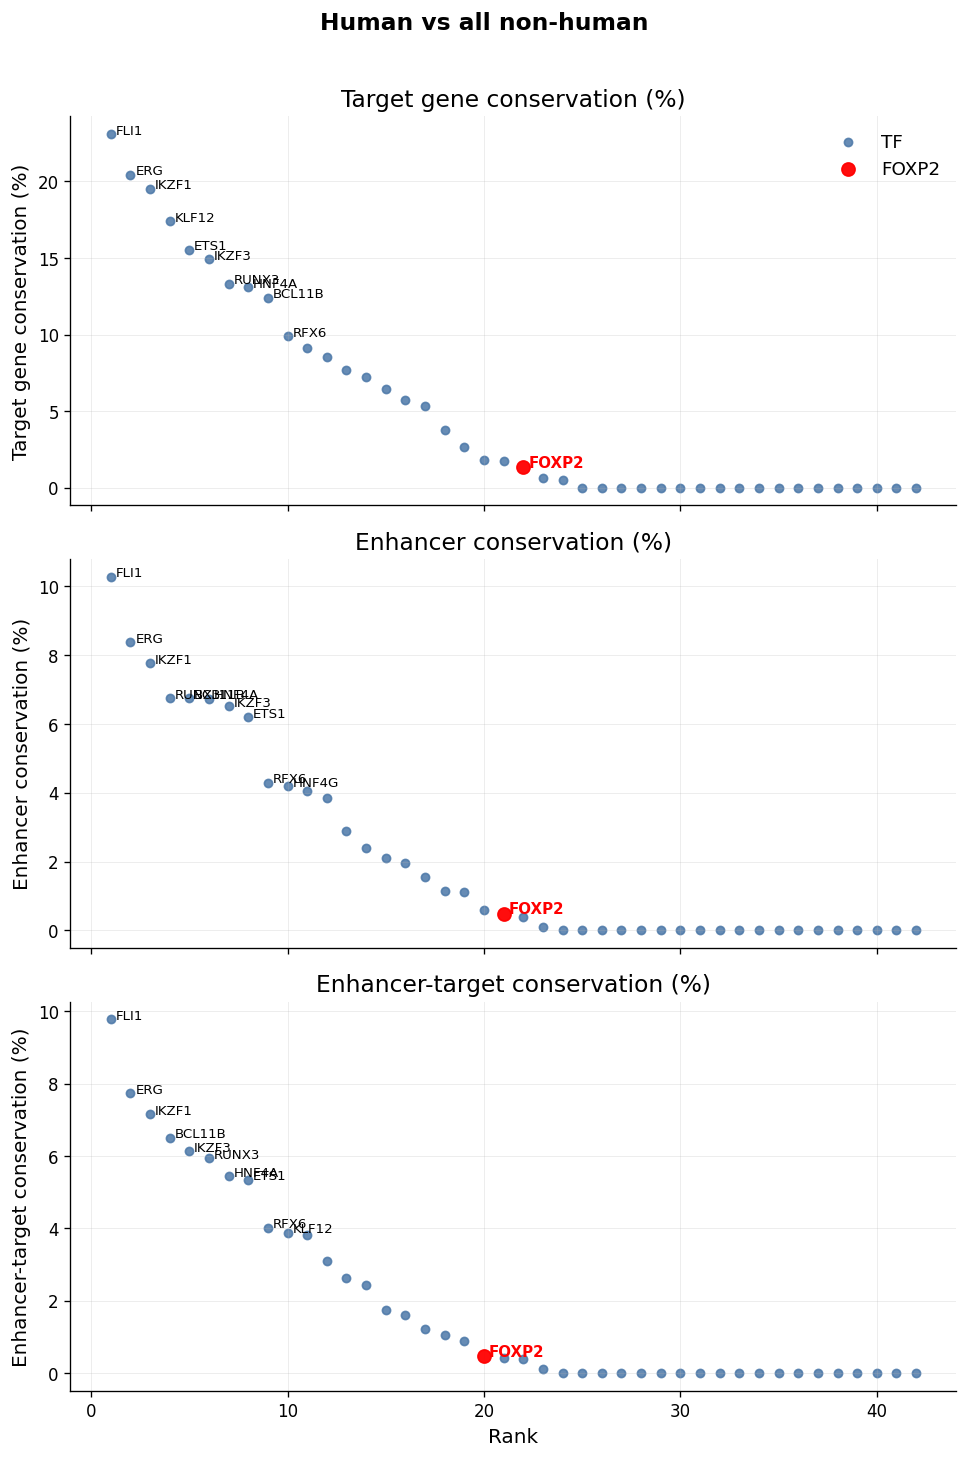

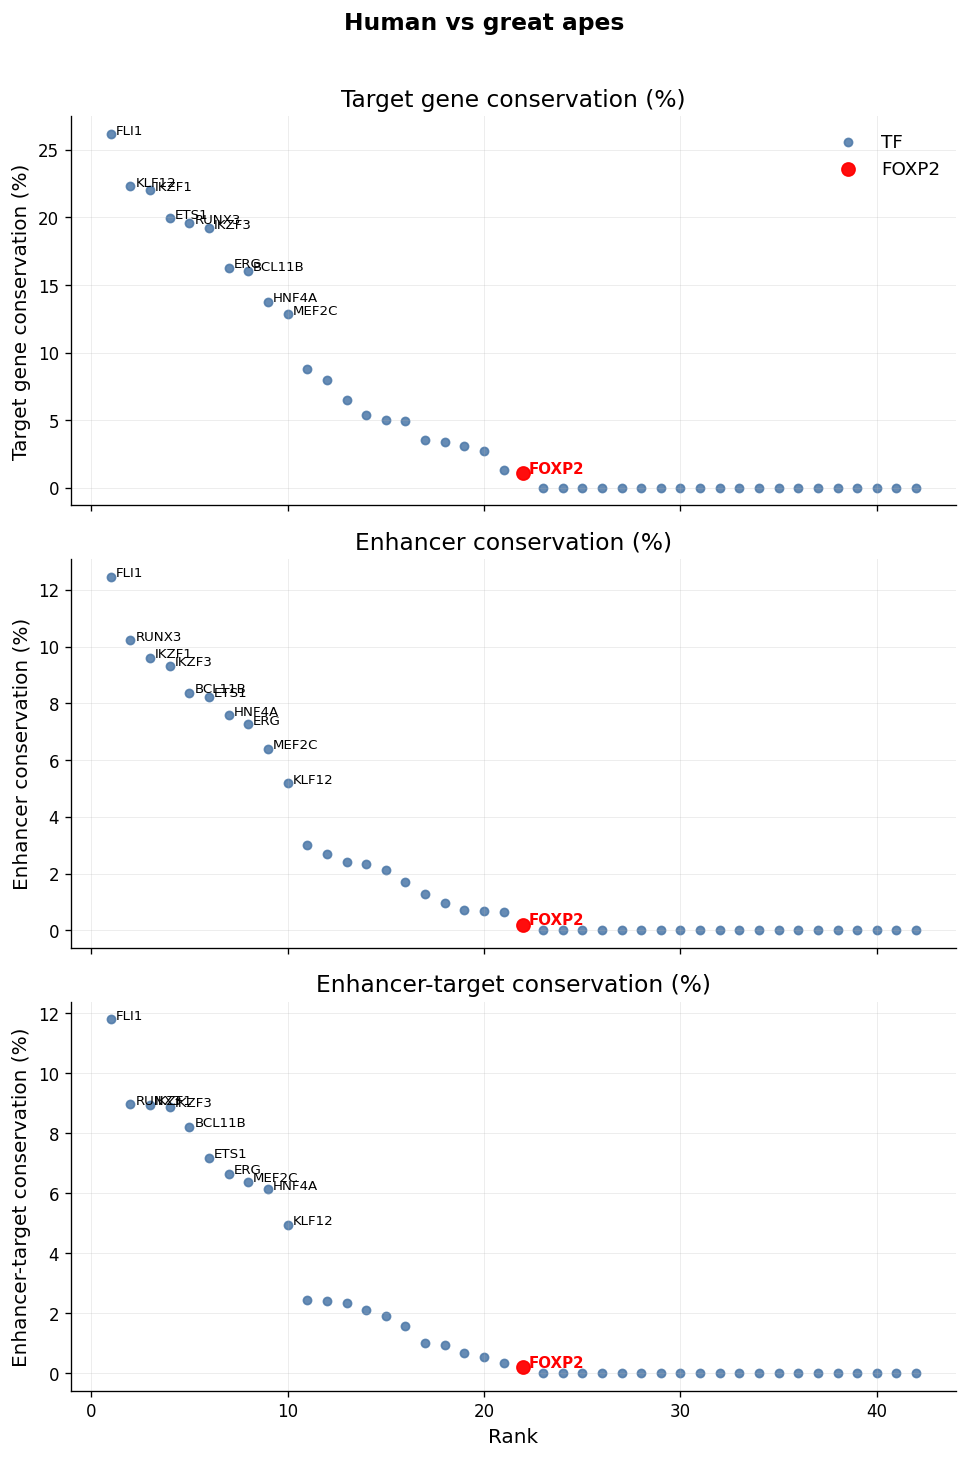

Saved files:
/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication/fig1_seed_level_summary.png
/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication/fig1_seed_level_summary.pdf
/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication/fig2_shared_tf_overlap_all_pairs.png
/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication/fig2_shared_tf_overlap_all_pairs.pdf
/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication/fig3_human_vs_others_overlap.png
/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication/fig3_human_vs_others_overlap.pdf
/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication/fig4_strict_hu

In [18]:
from pathlib import Path

FIG_OUT = Path('/home/jjanssens/jjans/analysis/adult_intestine/peaks/peak_calling/atac_pipeline/figures/scenicplus_publication')
FIG_OUT.mkdir(parents=True, exist_ok=True)

# Publication-style defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 400,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.linewidth': 0.6,
    'pdf.fonttype': 42,   # editable text in PDF
    'ps.fonttype': 42,
})


def save_pub(fig, stem: str):
    png_path = FIG_OUT / f'{stem}.png'
    pdf_path = FIG_OUT / f'{stem}.pdf'
    fig.savefig(png_path, bbox_inches='tight', dpi=400)
    fig.savefig(pdf_path, bbox_inches='tight')
    return png_path, pdf_path


saved = []

# 1) Seed-level summary figure
if {'run_level_plot', 'run_level_with_consistency', 'species_order'}.issubset(globals()):
    ordered_species = [s for s in species_order if s in run_level_with_consistency['species'].unique()]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    for sp in ordered_species:
        tmp = run_level_plot.loc[run_level_plot['species'] == sp].sort_values('seed_rank')
        axes[0].plot(tmp['seed_rank'], tmp['n_regulons'], marker='o', lw=1.8, ms=4.5, label=sp)
    axes[0].set_title('Regulons detected per run')
    axes[0].set_xlabel('Run index (categorical seed order)')
    axes[0].set_ylabel('Number of regulons')

    for sp in ordered_species:
        tmp = run_level_plot.loc[run_level_plot['species'] == sp].sort_values('seed_rank')
        axes[1].plot(tmp['seed_rank'], tmp['mean_regulon_links'], marker='o', lw=1.8, ms=4.5, label=sp)
    axes[1].set_title('Average regulon size per run')
    axes[1].set_xlabel('Run index (categorical seed order)')
    axes[1].set_ylabel('Mean links per regulon')

    cons_counts = (
        run_level_with_consistency[['species', 'n_regulons_consistent_all_seeds']]
        .drop_duplicates()
        .set_index('species')
        .reindex(ordered_species)
    )
    axes[2].bar(cons_counts.index, cons_counts['n_regulons_consistent_all_seeds'], color='#4C78A8')
    axes[2].set_title('Regulons consistent across all seeds')
    axes[2].set_xlabel('Species')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=25)

    axes[1].legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.tight_layout()
    saved.extend(save_pub(fig, 'fig1_seed_level_summary'))
    plt.show()

# 2) All species-pair overlap barplot
if 'bar_stats' in globals() and isinstance(bar_stats, pd.DataFrame) and not bar_stats.empty:
    pair_order = bar_stats['species_pair'].drop_duplicates().tolist()
    metric_order = ['TF-target gene', 'TF-enhancer', 'TF-to-TF']
    colors = {'TF-target gene': '#4C78A8', 'TF-enhancer': '#F58518', 'TF-to-TF': '#54A24B'}

    x = np.arange(len(pair_order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(12, len(pair_order) * 0.7), 5.2))
    for i, m in enumerate(metric_order):
        sub = bar_stats.loc[bar_stats['metric_label'] == m].set_index('species_pair').reindex(pair_order)
        means = sub['mean'].to_numpy(dtype=float)
        errs = sub['std'].fillna(0).to_numpy(dtype=float)
        ax.bar(x + (i - 1) * width, means, width=width, yerr=errs, capsize=3,
               label=m, color=colors[m], edgecolor='black', linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels(pair_order, rotation=45, ha='right')
    ax.set_ylabel('Overlap (%)')
    ax.set_title('Shared-TF overlap across species pairs (mean ± sd)')
    ax.legend(frameon=False)
    fig.tight_layout()
    saved.extend(save_pub(fig, 'fig2_shared_tf_overlap_all_pairs'))
    plt.show()

# 3) Human vs other species overlap barplot
if 'human_stats' in globals() and isinstance(human_stats, pd.DataFrame) and not human_stats.empty:
    other_order = [s for s in species_order if s in human_stats['other_species'].unique() and s != 'Human']
    metric_order = ['TF-target gene', 'TF-enhancer', 'TF-to-TF']
    colors = {'TF-target gene': '#4C78A8', 'TF-enhancer': '#F58518', 'TF-to-TF': '#54A24B'}

    x = np.arange(len(other_order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 4.8))
    for i, m in enumerate(metric_order):
        sub = human_stats.loc[human_stats['metric_label'] == m].set_index('other_species').reindex(other_order)
        means = sub['mean'].to_numpy(dtype=float)
        errs = sub['std'].fillna(0).to_numpy(dtype=float)
        ax.bar(x + (i - 1) * width, means, width=width, yerr=errs, capsize=3,
               label=m, color=colors[m], edgecolor='black', linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels(other_order, rotation=30, ha='right')
    ax.set_ylabel('Overlap (%)')
    ax.set_xlabel('Species (vs Human)')
    ax.set_title('Human vs other species: shared-TF overlap (mean ± sd)')
    ax.legend(frameon=False)
    fig.tight_layout()
    saved.extend(save_pub(fig, 'fig3_human_vs_others_overlap'))
    plt.show()

# 4) Strict human specificity barplot
if 'strict_human_specific_tfs' in globals() and 'strict_human_aspecific_tfs' in globals():
    fig, ax = plt.subplots(figsize=(5.8, 4.2))
    ax.bar(
        ['Strict Human-specific', 'Strict Human-aspecific'],
        [len(strict_human_specific_tfs), len(strict_human_aspecific_tfs)],
        color=['#4C78A8', '#F58518'],
        edgecolor='black',
        linewidth=0.3,
    )
    ax.set_ylabel('Number of TFs')
    ax.set_title('Strict human TF specificity (any-seed criterion)')
    ax.tick_params(axis='x', rotation=15)
    fig.tight_layout()
    saved.extend(save_pub(fig, 'fig4_strict_human_tf_specificity'))
    plt.show()

# 5) Ranking scatter plots (both styles x 3 metrics)
if 'rank_df' in globals() and isinstance(rank_df, pd.DataFrame) and not rank_df.empty:
    metric_specs = [
        ('avg_target_conservation_pct', 'Target gene conservation (%)', 'target'),
        ('avg_enhancer_conservation_pct', 'Enhancer conservation (%)', 'enhancer'),
        ('avg_both_conservation_pct', 'Enhancer-target conservation (%)', 'both'),
    ]
    styles_available = [s for s in ['Human vs all non-human', 'Human vs great apes'] if s in rank_df['style'].unique()]

    for style_name in styles_available:
        sub_style = rank_df.loc[rank_df['style'] == style_name].copy()

        fig, axes = plt.subplots(3, 1, figsize=(8.2, 12), sharex=True)
        top_labels = 10

        for ax, (metric_col, y_label, suffix) in zip(axes, metric_specs):
            plot_df = sub_style.sort_values(metric_col, ascending=False).reset_index(drop=True)
            plot_df['rank'] = np.arange(1, len(plot_df) + 1)
            is_foxp2 = plot_df['TF'].str.upper().eq('FOXP2')

            ax.scatter(
                plot_df.loc[~is_foxp2, 'rank'],
                plot_df.loc[~is_foxp2, metric_col],
                s=24,
                alpha=0.85,
                color='#4C78A8',
                label='TF',
            )

            if is_foxp2.any():
                ax.scatter(
                    plot_df.loc[is_foxp2, 'rank'],
                    plot_df.loc[is_foxp2, metric_col],
                    s=62,
                    alpha=0.95,
                    color='red',
                    label='FOXP2',
                    zorder=5,
                )

            for r in plot_df.head(top_labels).itertuples(index=False):
                ax.text(r.rank + 0.25, getattr(r, metric_col), r.TF, fontsize=8)

            if is_foxp2.any():
                fox = plot_df.loc[is_foxp2].iloc[0]
                ax.text(fox['rank'] + 0.25, fox[metric_col], 'FOXP2', fontsize=9, color='red', weight='bold')

            ax.set_ylabel(y_label)
            ax.set_title(y_label)

        axes[-1].set_xlabel('Rank')
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            uniq = dict(zip(labels, handles))
            axes[0].legend(uniq.values(), uniq.keys(), frameon=False, loc='upper right')

        fig.suptitle(style_name, y=1.01, fontsize=14, weight='bold')
        fig.tight_layout()

        style_slug = 'all_nonhuman' if 'all non-human' in style_name else 'great_apes'
        saved.extend(save_pub(fig, f'fig5_ranking_scatter_{style_slug}'))
        plt.show()

print('Saved files:')
for p in saved:
    print(p)